In [742]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
import numpy as np
import mne
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool
import torch_geometric
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
# from matplotlib.pyplot import pl
# import mne
from scipy.io import savemat
gkf=GroupKFold()

In [6]:
raw = mne.io.read_raw_gdf('/Users/siddharth/Downloads/BCICIV_2a_gdf/A01T.gdf', preload=True)

Extracting EDF parameters from /Users/siddharth/Downloads/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [13]:
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
raw.filter(l_freq=8., h_freq=30.)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom EEG reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 sec)



/Users/siddharth/opt/anaconda3/lib/python3.9/site-packages/mne/filter.py:313: DeprecationWarning: Keyword argument 'nyq' is deprecated in favour of 'fs' and will be removed in SciPy 1.12.0.
  this_h = firwin(this_N, (prev_freq + this_freq) / 2.,
/Users/siddharth/opt/anaconda3/lib/python3.9/site-packages/mne/filter.py:313: DeprecationWarning: Keyword argument 'nyq' is deprecated in favour of 'fs' and will be removed in SciPy 1.12.0.
  this_h = firwin(this_N, (prev_freq + this_freq) / 2.,


<RawGDF | A01T.gdf, 22 x 672528 (2690.1 s), ~112.9 MB, data loaded>

In [14]:
events = mne.events_from_annotations(raw)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']


In [15]:
epoch = mne.Epochs(raw,events[0],event_id=[7,8,9,10],tmin = -0.1,tmax=0.7,on_missing='warn')

Not setting metadata
Not setting metadata
288 matching events found
Setting baseline interval to [-0.1, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated


In [16]:
epoch = mne.Epochs(raw,events[0],event_id=[7,8,9,10],tmin = -0.1,tmax=0.7,on_missing='warn')

Not setting metadata
Not setting metadata
288 matching events found
Setting baseline interval to [-0.1, 0.0] sec
Applying baseline correction (mode: mean)
0 projection items activated


In [19]:
data = epoch.get_data()

Loading data for 288 events and 201 original time points ...


In [21]:
from scipy.signal import welch

/Users/siddharth/opt/anaconda3/lib/python3.9/site-packages/scipy/signal/_spectral_py.py:2014: UserWarning: nperseg = 500 is greater than input length  = 201, using nperseg = 201
  warnings.warn('nperseg = {0:d} is greater than input length '


In [23]:
print(band_powers.shape)

(288, 22)


In [202]:
def read_data(path):
  raw = mne.io.read_raw_gdf(path,eog=['EOG-left', 'EOG-central', 'EOG-right'],preload=True)
  raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
  raw.set_eeg_reference()
  raw.filter(l_freq=8., h_freq=30.)
  events = mne.events_from_annotations(raw)
  epoch = mne.Epochs(raw,events[0],event_id=[7,8,9,10],tmin = -0.1,tmax=0.7,on_missing='warn')
  labels= epoch.events[:,-1] 
  features= epoch.get_data()
  return features,labels

1. artifiact removal (if 1023 drop)
2. preprocess the data (band pass filtering [8 to 30 hz ] )
3. calculate band power for each channel
4. Train GCN
       a. Subject Specific - Train with one subject training and test with same subject evalutaion (). Tune model 9 times. save the parameters and then we can use for the 2nd approach.
       2. Leave One subject out - Train with 8 subjects(train + evalution) and test with remaning subject (train + eval)
       3. Train with all subject training data and then test it on different subjects (9 different accuracy for subject but train only once) 

Brain connectivty toolbox matlab
 using this we can calculate different nodal feature
Effective Connectivty
Structural Connectivity 


In [275]:
def read_data_bandpower(path):
  raw = mne.io.read_raw_gdf(path,eog=['EOG-left', 'EOG-central', 'EOG-right'],preload=True)
  raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
  raw.set_eeg_reference()
  raw.filter(l_freq=8., h_freq=30.)
  events = mne.events_from_annotations(raw)
  epoch = mne.Epochs(raw,events[0],event_id=[7,8,9,10],tmin = -0.1,tmax=0.7,on_missing='warn')
  labels= epoch.events[:,-1] 
  data = epoch.get_data()
  sfreq = raw.info['sfreq']
  # Calculate power using Welch's method for each channel and each epoch
  band_powers = []

  for epoch in data:  # Loop over each epoch
      epoch_powers = []
      for channel_data in epoch:  # Loop over each channel in the epoch
          freqs, psd = welch(channel_data, sfreq, nperseg=sfreq*2)  # Compute the PSD
          # Compute the band power by integrating the power spectral density (PSD) in the 8-30 Hz band
          band_power = np.trapz(psd[(freqs >= 8) & (freqs <= 30)], freqs[(freqs >= 8) & (freqs <= 30)])
          epoch_powers.append(band_power)
      band_powers.append(epoch_powers)

  band_powers = np.array(band_powers)
  features= band_powers
  return features,labels

In [ ]:
train_data = []
train_label = []

for i in range(1, 10):
    features, labels = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A0{i}T.gdf')
    if len(train_data) == 0:
        train_data = features
        train_label = labels
    else:
        train_data = np.concatenate((train_data, features), axis=0)
        train_label = np.concatenate((train_label, labels), axis=0)


In [ ]:
features, labels = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A03E.gdf')
features1, labels1 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A04E.gdf')
features2, labels2 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A05E.gdf')
features3, labels3 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A06E.gdf')
features4, labels4 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A07E.gdf')
features5, labels5 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A08E.gdf')
features6, labels6 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A09E.gdf')
features7, labels7 = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A02E.gdf')

In [278]:
test_data = np.concatenate((features, features1, features2, features3, features4, features5, features6, features7), axis=0)

In [279]:
test_label = np.concatenate((labels, labels1, labels2, labels3, labels4, labels5, labels6,labels7), axis=0)

In [280]:
train_label = train_label-7
test_label = test_label-7

In [281]:
test_label.shape
test_data.shape
train_data.shape
train_label.shape

(2448,)

In [282]:
print(test_data.shape)
print(test_label.shape)
print(train_data.shape)
print(train_label.shape)

(2304, 22, 201)
(2304,)
(2448, 22, 201)
(2448,)


1. Subject Specific - Train with one subject training and test with same subject evalutaion (). Tune model 9 times. save the parameters and then we can use for the 2nd approach.
2. Leave One subject out - Train with 8 subjects(train + evalution) and test with remaning subject (train + eval)
3. Train with all subject training data and then test it on different subjects (9 different accuracy for subject but train only once) 

In [59]:
# data = np.moveaxis(data, 1, 2)
# data.shape

In [6]:
adjacency_matrices = data
labels=label

In [283]:
import torch
from torch_geometric.data import Data, Dataset
import numpy as np

class SequentialGraphDataset(Dataset):
    def __init__(self, event_data, labels, edge_index=None, transform=None, pre_transform=None):
        """
        :param event_data: The input data of shape (num_events, num_channels, sequence_length)
        :param labels: Labels of shape (num_events,)
        :param edge_index: Predefined edge index for the graph (optional). Shape should be (2, num_edges)
        """
        self.event_data = event_data  # The event data is (num_events, channels, sequence_length)
        self.labels = labels  # Labels for each event
        self.edge_index = edge_index  # Edge index can be predefined or constructed later
        super(SequentialGraphDataset, self).__init__(None, transform, pre_transform)

    def len(self):
        return len(self.labels)

    def get(self, idx):
        self.event_data = (self.event_data - np.mean(self.event_data, axis=1, keepdims=True)) / np.std(self.event_data, axis=1, keepdims=True)
        # Node features: Use the sequence for each channel as node features
        # In this case, each node has a feature vector of length `sequence_length`
        x = torch.tensor(self.event_data[idx], dtype=torch.float)  # Shape: (channels, sequence_length)

        # If no predefined edge_index, create a fully connected graph
        if self.edge_index is None:
            num_channels = x.size(0)
            edge_index = self.create_fully_connected_edge_index(num_channels)
        else:
            edge_index = self.edge_index

        # Create the label tensor
        y = torch.tensor([self.labels[idx]], dtype=torch.long)
        batch = torch.full((x.size(0),), idx, dtype=torch.long)
        # Return the data object
        data = Data(x=x, edge_index=edge_index, y=y,batch=batch)
        return data

    @staticmethod
    def create_fully_connected_edge_index(num_nodes):
        """ Creates a fully connected graph where each node is connected to every other node. """
        edge_index = []
        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    edge_index.append([i, j])
        return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Split the dataset into training and testing sets (Thos os no)
# train_indices, test_indices = train_test_split(range(len(labels)), test_size=0.2, random_state=42)
# train_data = adjacency_matrices[train_indices]
# test_data = adjacency_matrices[test_indices]
# train_labels = labels[train_indices]
# test_labels = labels[test_indices]
# train_data,train_label = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A01T.gdf')
# test_data,test_label = read_data(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/A01E.gdf')
# Create the datasets
train_dataset = SequentialGraphDataset(train_data, train_label)
test_dataset = SequentialGraphDataset(test_data, test_label)

In [292]:
train_dataset[0]

Data(x=[22, 201], edge_index=[2, 462], y=[1], batch=[22])

In [285]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        # GCN branch
        self.gcn1 = GCNConv(num_node_features, hidden_channels )
        self.gcn2 = GCNConv(hidden_channels, 50)
        # GAT branch
        self.gat1 = GATConv(num_node_features, hidden_channels)
        self.gat2 = GATConv(hidden_channels, 50)
        # Chebyshev branch
        self.cheb1 = ChebConv(num_node_features, hidden_channels, K=2)
        self.cheb2 = ChebConv(hidden_channels, 50, K=2)
        # GraphSAGE branch
        self.sage1 = SAGEConv(num_node_features, hidden_channels)
        self.sage2 = SAGEConv(hidden_channels, 50)
        # Fully connected layer for classification
        self.fc = torch.nn.Linear(50 * 4, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = x.view(-1, 1)        
        x_gcn = F.relu(self.gcn1(x, edge_index))
        x_gcn = F.dropout(x_gcn, training=self.training)
        x_gcn = F.relu(self.gcn2(x_gcn, edge_index))

        # GAT branch
        x_gat = F.relu(self.gat1(x, edge_index))
        x_gat = F.dropout(x_gat, training=self.training)
        x_gat = F.relu(self.gat2(x_gat, edge_index))

        # Chebyshev branch
        x_cheb = F.relu(self.cheb1(x, edge_index))
        x_cheb = F.dropout(x_cheb, training=self.training)
        x_cheb = F.relu(self.cheb2(x_cheb, edge_index))

        # GraphSAGE branch
        x_sage = F.relu(self.sage1(x, edge_index))
        x_sage = F.dropout(x_sage, training=self.training)
        x_sage = F.relu(self.sage2(x_sage, edge_index))

        # Concatenate the outputs from all branches
        x = torch.cat((x_gcn, x_gat, x_cheb, x_sage), dim=1)

        # Apply the pooling layer to get graph-level representation
        x = torch_geometric.nn.global_mean_pool(x, data.batch)

        # Apply the classification layer
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [286]:
import torch_geometric
hidden_channels = 100  # Number of hidden units
num_node_features = 1  # This is the sequence length
num_classes = 4  # Assuming binary classification, adjust based on your dataset

# Initialize the model
model = GCN(num_node_features, hidden_channels, num_classes)
print(model)

GCN(
  (gcn1): GCNConv(1, 100)
  (gcn2): GCNConv(100, 50)
  (gat1): GATConv(1, 100, heads=1)
  (gat2): GATConv(100, 50, heads=1)
  (cheb1): ChebConv(1, 100, K=2, normalization=sym)
  (cheb2): ChebConv(100, 50, K=2, normalization=sym)
  (sage1): SAGEConv(1, 100, aggr=mean)
  (sage2): SAGEConv(100, 50, aggr=mean)
  (fc): Linear(in_features=200, out_features=4, bias=True)
)


In [287]:
print(len(train_dataset))
print(len(test_dataset))

2448
2304


In [148]:
test_label.min()

0

In [ ]:
import torch.optim as optim  # Import torch.optim for the optimizer


def train_model(train_dataset, test_dataset, model, num_epochs=25, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Train loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            out = model(data)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = out.max(dim=1)
            correct += (predicted == data.y).sum().item()
            total += data.y.size(0)

        train_accuracy = correct / total
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
        
    # Evaluate on the test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data)
            _, predicted = out.max(dim=1)
            correct += (predicted == data.y).sum().item()
            total += data.y.size(0)
            
    test_accuracy = correct / total
    print(f'Test Accuracy: {test_accuracy:.4f}')
    return model, test_accuracy

model = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, num_classes=num_classes)
trained_model, accuracy = train_model(train_dataset, test_dataset, model)

In [ ]:
from torch.optim.lr_scheduler import StepLR
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()
# Prepare DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Training function
def train():
    model.train()
    total_loss = 0
    for data in train_loader:  # Iterate over batches
        optimizer.zero_grad()   # Clear gradients
        out = model(data)       # Perform forward pass
        loss = criterion(out, data.y)  # Compute the loss
        loss.backward()         # Backpropagate the loss
        optimizer.step()        # Update weights
        total_loss += loss.item()  # Accumulate loss
    return total_loss / len(train_loader)

# Testing function
def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data)  # Forward pass
        pred = out.argmax(dim=1)  # Get class predictions
        correct += (pred == data.y).sum().item()  # Compare predictions to actual
    return correct / len(loader.dataset)

# Training loop
num_epochs = 100
for epoch in range(1, num_epochs+1):
    loss = train()  # Train the model
    train_acc = test(train_loader)  # Check accuracy on the training set
    # test_acc = test(test_loader)  # Check accuracy on the test set
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}')


In [176]:
train_indices, test_indices = train_test_split(range(len(train_label)), test_size=0.2, random_state=42)
train_dataset = SequentialGraphDataset(train_data[train_indices], train_label[train_indices])
test_dataset = SequentialGraphDataset(train_data[test_indices],  train_label[test_indices])

In [177]:
min(train_indices)

0

In [178]:
test_data[0]

array([3.16562481e-12, 7.41810609e-12, 4.66898681e-12, 2.14541480e-12,
       2.82818304e-12, 4.96340067e-12, 5.49753270e-12, 5.45171977e-12,
       2.83221847e-12, 1.48273225e-12, 1.55528164e-12, 3.17422049e-12,
       7.12938845e-12, 2.88255253e-12, 1.90377579e-12, 1.70958572e-12,
       1.42964688e-12, 2.16587502e-12, 4.83586137e-12, 3.59486773e-12,
       3.93034515e-12, 6.71427839e-12])

In [ ]:

from torch.optim.lr_scheduler import StepLR
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
# scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
criterion = torch.nn.CrossEntropyLoss()
# Prepare DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Training function
def train():
    model.train()
    total_loss = 0
    for data in train_loader:  # Iterate over batches
        optimizer.zero_grad()   # Clear gradients
        out = model(data)
        # print(out.shape)
        # print(data.y.shape)       # Perform forward pass
        loss = criterion(out, data.y)  # Compute the loss
        loss.backward()         # Backpropagate the loss
        optimizer.step()        # Update weights
        total_loss += loss.item()  # Accumulate loss
    return total_loss / len(train_loader)

# Testing function
def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data)  # Forward pass
        pred = out.argmax(dim=1)  # Get class predictions
        correct += (pred == data.y).sum().item()  # Compare predictions to actual
    return correct / len(loader.dataset)

# Training loop
num_epochs = 20
for epoch in range(1, num_epochs+1):
    loss = train()  # Train the model
    train_acc = test(train_loader)  # Check accuracy on the training set
    test_acc = test(test_loader)  # Check accuracy on the test set
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

In [30]:
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, GCNConv, GATConv, SAGEConv
import torch.nn as nn
import torch

# Normalize adjacency matrix and compute Chebyshev polynomial
def normalize_A(A, lmax=2):
    A = F.relu(A)
    N = A.shape[0]
    A = A * (torch.ones(N, N) - torch.eye(N, N))
    A = A + A.T
    d = torch.sum(A, 1)
    d = 1 / torch.sqrt(d + 1e-10)
    D = torch.diag_embed(d)
    L = torch.eye(N, N) - torch.matmul(torch.matmul(D, A), D)
    Lnorm = (2 * L / lmax) - torch.eye(N, N)
    return Lnorm

def generate_cheby_adj(L, K):
    support = []
    for i in range(K):
        if i == 0:
            support.append(torch.eye(L.shape[-1]))
        elif i == 1:
            support.append(L)
        else:
            temp = torch.matmul(2 * L, support[-1]) - support[-2]
            support.append(temp)
    return support

class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, bias=False):
        super(GraphConvolution, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_channels, out_channels))
        nn.init.xavier_normal_(self.weight)
        self.bias = nn.Parameter(torch.FloatTensor(out_channels)) if bias else None
        if bias:
            nn.init.zeros_(self.bias)

    def forward(self, x, adj):
        out = torch.matmul(adj, x)
        out = torch.matmul(out, self.weight)
        if self.bias is not None:
            return out + self.bias
        else:
            return out

class Chebynet(nn.Module):
    def __init__(self, in_channels, K, out_channels):
        super(Chebynet, self).__init__()
        self.K = K
        self.gc = nn.ModuleList([GraphConvolution(in_channels, out_channels) for _ in range(K)])
        self.pool = global_mean_pool  # Add a pooling layer

    def forward(self, x, L, batch):
        adj = generate_cheby_adj(L, self.K)
        result = sum([self.gc[i](x, adj[i]) for i in range(len(self.gc))])
        result = self.pool(result, batch)  # Pool over the batch to get one vector per graph
        return F.log_softmax(result, dim=1)

In [ ]:
# Adjust the model initialization parameters based on input data characteristics
from torch_geometric.utils import to_dense_adj
hidden_channels = 100  # Number of hidden units
num_node_features = 201  # Sequence length
num_classes = 4  # Number of classes in your dataset

# Initialize the DGCNN model (ensure parameters match your dataset)
model = Chebynet(in_channels=num_node_features, K=2, out_channels=hidden_channels)
print(model)
# Define the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Prepare DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Training function
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        x = data.x
        edge_index = data.edge_index
        adj = to_dense_adj(edge_index)
        L = normalize_A(adj)
        out = model(x, L, data.batch)  # Pass batch indices to the model
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data in loader:
            x = data.x
            edge_index = data.edge_index
            adj = to_dense_adj(edge_index)
            L = normalize_A(adj)
            out = model(x, L, data.batch)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)

# Training loop
num_epochs = 20  # Define the number of epochs
for epoch in range(1, num_epochs + 1):
    loss = train()  # Train the model
    train_acc = test(train_loader)  # Check accuracy on the training set
    test_acc = test(test_loader)  # Check accuracy on the test set
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

In [ ]:
from torch_geometric.utils import to_dense_adj
for data in train_loader:
    optimizer.zero_grad()
    x = data.x
    edge_index = data.edge_index
    adj = to_dense_adj(edge_index)
    L = normalize_A(adj)
    out = model(x, L, data.batch)
    print(out.shape)
    print(out)
    print(data.y)
    print(data.y.shape) # Pass batch indices to the model
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

In [2]:
edge_index = []
for i in range(22):
    for j in range(22):
        if i != j:
            edge_index.append([i, j])

In [263]:
def compute_connectivity(data):
    """
    Compute the Pearson correlation between each pair of channels.
    Parameters:
    data (numpy array): The input EEG data of shape (channels, datapoints).
    Returns:
    connectivity_matrix (numpy array): A matrix of shape (channels, channels) representing connectivity.
    """
    return np.corrcoef(data)

def create_graph_from_connectivity(connectivity_matrix, threshold=0.3):
    """
    Create a graph from the connectivity matrix.
    Parameters:
    connectivity_matrix (numpy array): The connectivity matrix of shape (channels, channels).
    threshold (float): The threshold for filtering weak connections.
    Returns:
    Data: A PyTorch Geometric graph data object.
    """
    num_channels = connectivity_matrix.shape[0]
    node_features = torch.eye(num_channels, dtype=torch.float)  # Placeholder features (identity matrix)
    
    # Create edges based on threshold
    edge_index = []
    edge_attr = []
    
    for i in range(num_channels):
        for j in range(i+1, num_channels):
            if abs(connectivity_matrix[i, j]) > threshold:
                edge_index.append([i, j])
                edge_index.append([j, i])
                edge_attr.append(connectivity_matrix[i, j])
                edge_attr.append(connectivity_matrix[i, j])
    
    eedge_index = torch.tensor(edge_index, dtyp=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)


In [ ]:
for i, event in enumerate(dataset):
    connectivity_matrix = compute_connectivity(event)
    print(connectivity_matrix.shape)

In [ ]:
def create_graphs_for_all_events(dataset, labels, threshold=0.3):
    all_graphs = []
    for i, event in enumerate(dataset):
        connectivity_matrix = compute_connectivity(event)
        graph_data = create_graph_from_connectivity(connectivity_matrix, threshold)
        graph_data.y = torch.tensor([labels[i]], dtype=torch.long)  # Add label for classification
        all_graphs.append(graph_data)
    return all_graphs

# Create the graphs and labels

# Example dataset of shape (events, channels, datapoints)
# events, channels, datapoints = 100, 32, 500
dataset,data_label = read_data('/Users/siddharth/Downloads/BCICIV_2a_gdf/A01T.gdf')
dataset.shape  # Random data for example
data_label = data_label-7
graph_list = create_graphs_for_all_events(dataset, data_label)

In [273]:
len(graph_list)

288

In [256]:
fs = 500  # Sampling frequency
freq_range = (8, 30)  # Frequency range of interest
time = np.arange(0, 1, 1/fs)  # Time array (1 second of data)
coh_matrix, freqs = connectivity_coh(dataset, fs, freq_range, time, complex_type='abs')
all_graphs = []
connectivity_matrix = coh_matrix[:,:,0]
graph_data = create_graph_from_connectivity(connectivity_matrix, threshold=0.5)
graph_data.y = torch.tensor([labels[i]], dtype=torch.long)  # Add label for classification
all_graphs.append(graph_data)



In [260]:
all_graphs

[Data(x=[22, 22], edge_index=[2, 224], edge_attr=[224], y=[1])]

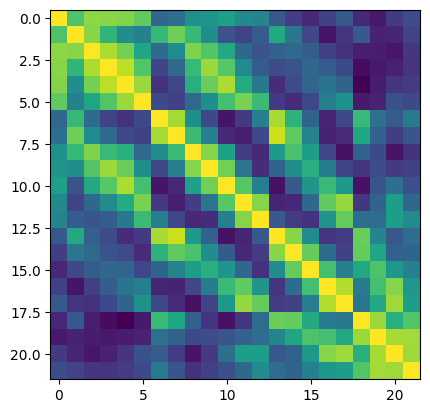

In [221]:
coh_matrix.shape

In [224]:
import numpy as np
from scipy.signal import welch, coherence
from scipy.fft import fft


In [227]:
import numpy as np
from scipy.fft import fft, fftfreq

def connectivity_coh(data, fs, freq_range, time, complex_type='abs'):
    """
    Parameters:
        data (np.ndarray): Input data of shape (trials x channels x points)
        fs (int): Sampling frequency
        freq_range (tuple): Frequency range for coherency (low_freq, high_freq)
        time (np.ndarray): Time array
        complex_type (str): 'abs' for absolute coherence or 'imag' for imaginary part of coherence

    Returns:
        coherency_network_per_frequency (np.ndarray): Coherency matrix (channels x channels x freq)
        freqoi (np.ndarray): Frequency of interest range
    """
    num_trial, num_chan, _ = data.shape if len(data.shape) == 3 else (1, data.shape[0], data.shape[1])

    # Define number of points for FFT
    n_points = data.shape[2]

    # Define frequency bins
    freq_bins = fftfreq(n_points, d=1/fs)[:n_points // 2]  # Only take positive frequencies

    # Perform Fourier transform for each trial and channel
    fourier_spectrum = np.zeros((num_trial, num_chan, len(freq_bins)), dtype=complex)

    for trl in range(num_trial):
        for chan in range(num_chan):
            # Compute Fourier Transform for each channel
            fourier_spectrum[trl, chan, :] = fft(data[trl, chan, :])[:n_points // 2]  # Take only positive frequencies

    # Coherency calculation
    coherency_network_per_frequency = np.zeros((num_chan, num_chan, len(freq_bins)))

    for sig1 in range(num_chan):
        freqSig1 = fourier_spectrum[:, sig1, :]
        for sig2 in range(num_chan):
            freqSig2 = fourier_spectrum[:, sig2, :]

            # Cross-spectrum
            XSpec = np.mean(freqSig1 * np.conj(freqSig2), axis=0)

            # Auto-spectrum
            spec1 = np.mean(freqSig1 * np.conj(freqSig1), axis=0)
            spec2 = np.mean(freqSig2 * np.conj(freqSig2), axis=0)

            # Coherency calculation
            C = XSpec / np.sqrt(spec1 * spec2)

            if complex_type == 'abs':
                C = np.abs(C)  # Power coherence
            elif complex_type == 'imag':
                C = np.imag(C)  # Phase coherence

            # Store coherency values
            coherency_network_per_frequency[sig1, sig2, :] = C

    # Filter the frequency bins based on the specified frequency range
    freq_mask = (freq_bins >= freq_range[0]) & (freq_bins <= freq_range[1])
    freqoi = freq_bins[freq_mask]

    # Return the coherency matrix for the selected frequencies only
    return coherency_network_per_frequency[:, :, freq_mask], freqoi

# Example usage
fs = 500  # Sampling frequency
freq_range = (8, 30)  # Frequency range of interest
time = np.arange(0, 1, 1/fs)  # Time array (1 second of data)

# Simulated data: 288 trials, 22 channels, 201 datapoints

# Call the function
coh_matrix, freqs = connectivity_coh(dataset, fs, freq_range, time, complex_type='abs')

print("Coherency matrix shape:", coh_matrix.shape)
print("Frequencies of interest:", freqs)


Coherency matrix shape: (22, 22, 9)
Frequencies of interest: [ 9.95024876 12.43781095 14.92537313 17.41293532 19.90049751 22.3880597
 24.87562189 27.36318408 29.85074627]


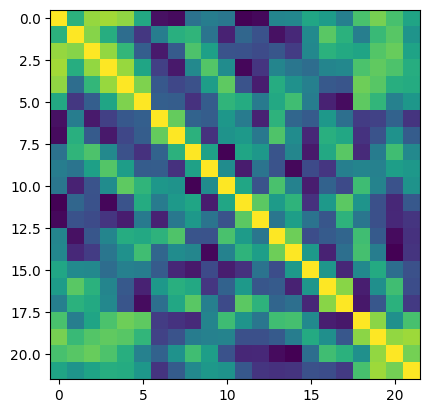

In [251]:
plt.imshow(coh_matrix[:,:,8])

In [231]:
connectivity_matrix.shape

(22, 9)

In [14]:
import matplotlib.pyplot as plt
import mne
import scipy

In [138]:
subject_name = 'A07T'
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/{subject_name}.gdf',
                          eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',
    'EEG-1': 'FC1',
    'EEG-2': 'FCz',
    'EEG-3': 'FC2',
    'EEG-4': 'FC4',
    'EEG-5': 'C5',
    'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
    'EEG-6': 'C1',
    'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
    'EEG-7': 'C2',
    'EEG-C4' : 'C4',
    'EEG-8': 'C6',
    'EEG-9': 'CP3',
    'EEG-10': 'CP1',
    'EEG-11': 'CPz',
    'EEG-12': 'CP2',
    'EEG-13': 'CP4',
    'EEG-14': 'P1',
    'EEG-Pz': 'Pz',
    'EEG-15': 'P2',
    'EEG-16': 'POz'
}

# Rename the channels using the updated dictionary
raw.rename_channels(channel_rename_dict)

# print(raw.info['ch_names'])

montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
# Step 2: Extract events and create epochs
events = mne.events_from_annotations(raw)

print(events)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

labels = epoch.events[:, -1] - 7

# Step 3: Apply baseline correction
epoch.apply_baseline((-1.5, 0.0))

# Step 4: Ensure data is loaded into memory
epoch.load_data()

# Step 5: Select signal between t = 3 and t = 6
epoch_cropped = epoch.crop(tmin=3, tmax=6)

# Step 6: Apply a Notch filter at 50 Hz
picks = mne.pick_types(epoch_cropped.info, eeg=True)  # Pick EEG channels

epoch_cropped._data = mne.filter.notch_filter(epoch_cropped.get_data(),
                                              Fs=epoch_cropped.info['sfreq'],
                                              freqs=50,
                                              picks=picks,
                                              method='spectrum_fit')

iir_params = {
    'order': 5,  # 5th-order filter
    'ftype': 'butter',  # Butterworth filter
}

epoch_cropped._data = mne.filter.filter_data(
    epoch_cropped.get_data(),
    sfreq=epoch_cropped.info['sfreq'],  # Sampling frequency
    l_freq=0.5,  # Low cutoff frequency
    h_freq=48,   # High cutoff frequency
    picks=picks, # Channels to apply the filter to
    iir_params=iir_params,
    # phase='zero',       # Linear-phase filtering
    # pad='edge',         # Padding to minimize edge effects
    method='iir'  # Filter method (IIR is commonly used)
)

# Step 7: Extract features for each class
features_769 = epoch_cropped['769'].get_data()  # Features for event 769
features_770 = epoch_cropped['770'].get_data()  # Features for event 770

Extracting EDF parameters from /Users/siddharth/Downloads/BCICIV_2a_gdf/A07T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 681070  =      0.000 ...  2724.280 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 27170,      0,      5],
       ...,
       [677534,      0,      7],
       [679093,      0,      6],
       [679593,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3168 windows
Setting up band-pass filter from 0.5 - 1e+02 Hz

IIR filter parameters
---------------------
Butterwor

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


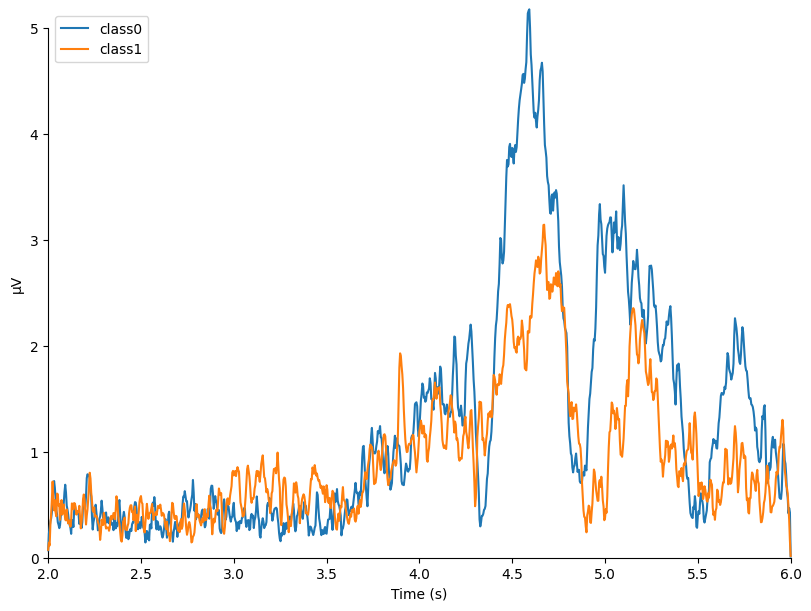

[<Figure size 800x600 with 1 Axes>]

In [139]:
evoked_0 = epoch['769'].average()
evoked_1 = epoch['770'].average()
# evoked_2 = epoch['9'].average()
# evoked_3 = epoch['10'].average()

dicts={'class0':evoked_0,'class1':evoked_1}
mne.viz.plot_compare_evokeds(dicts)

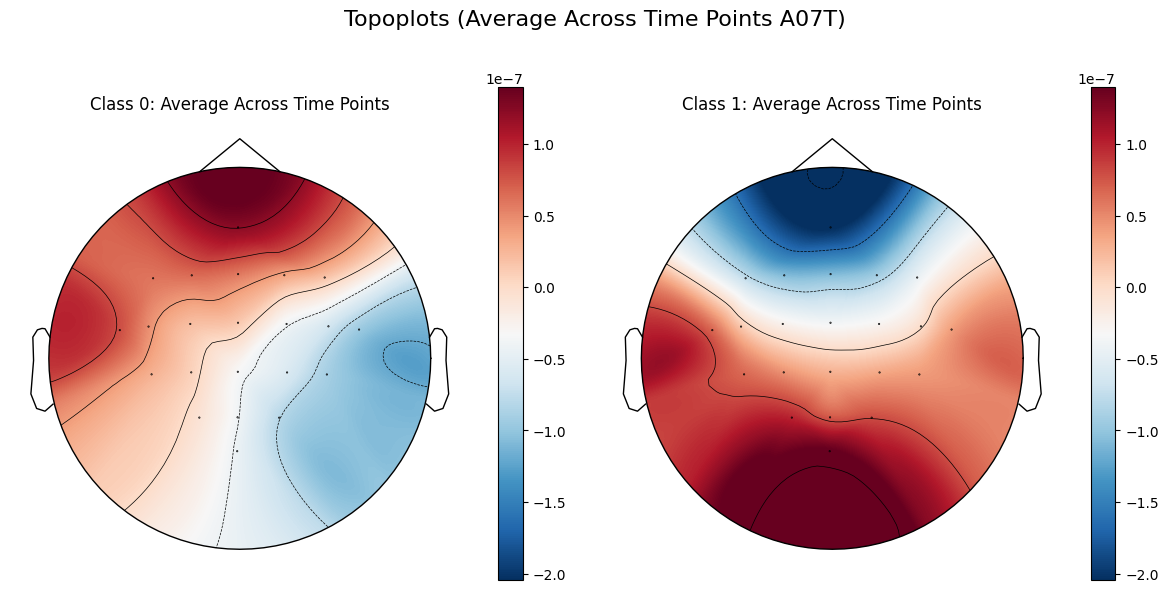

In [140]:
# Step 1: Compute the ERP (average across trials) for each class
erp_class_0 = epoch_cropped['769'].average()  # ERP for class 0
erp_class_1 = epoch_cropped['770'].average()  # ERP for class 1

# Step 2: Average across time points for each channel
avg_erp_class_0 = erp_class_0.data.mean(axis=1)  # Shape: (channels,)
avg_erp_class_1 = erp_class_1.data.mean(axis=1)  # Shape: (channels,)

# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (Average Across Time Points {subject_name})", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(avg_erp_class_0.min(), avg_erp_class_1.min())
vmax = max(avg_erp_class_0.max(), avg_erp_class_1.max())

# Class 0
im_0, _ = mne.viz.plot_topomap(avg_erp_class_0, erp_class_0.info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: Average Across Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(avg_erp_class_1, erp_class_1.info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: Average Across Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure


In [153]:
for i in range(1,10):
    subject_name = f'A0{i}T'
    raw = mne.io.read_raw_gdf(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/{subject_name}.gdf',
                            eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    raw.set_eeg_reference()
    channel_rename_dict = {
        'EEG-Fz': 'Fz',
        'EEG-0': 'FC3',
        'EEG-1': 'FC1',
        'EEG-2': 'FCz',
        'EEG-3': 'FC2',
        'EEG-4': 'FC4',
        'EEG-5': 'C5',
        'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
        'EEG-6': 'C1',
        'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
        'EEG-7': 'C2',
        'EEG-C4' : 'C4',
        'EEG-8': 'C6',
        'EEG-9': 'CP3',
        'EEG-10': 'CP1',
        'EEG-11': 'CPz',
        'EEG-12': 'CP2',
        'EEG-13': 'CP4',
        'EEG-14': 'P1',
        'EEG-Pz': 'Pz',
        'EEG-15': 'P2',
        'EEG-16': 'POz'
    }

    # Rename the channels using the updated dictionary
    raw.rename_channels(channel_rename_dict)

    # print(raw.info['ch_names'])

    montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
    raw.set_montage(montage)
    # Step 2: Extract events and create epochs
    events = mne.events_from_annotations(raw)

    print(events)
    epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

    labels = epoch.events[:, -1] - 7

    # Step 3: Apply baseline correction
    epoch.apply_baseline((-1.5, 0.0))

    # Step 4: Ensure data is loaded into memory
    epoch.load_data()

    # Step 5: Select signal between t = 3 and t = 6
    epoch_cropped = epoch.crop(tmin=3, tmax=6)
    # Step 6: Apply a Notch filter at 50 Hz
    picks = mne.pick_types(epoch_cropped.info, eeg=True)  # Pick EEG channels

    epoch_cropped._data = mne.filter.notch_filter(epoch_cropped.get_data(),
                                                Fs=epoch_cropped.info['sfreq'],
                                                freqs=50,
                                                picks=picks,
                                                method='spectrum_fit')

    iir_params = {
        'order': 5,  # 5th-order filter
        'ftype': 'butter',  # Butterworth filter
    }

    epoch_cropped._data = mne.filter.filter_data(
        epoch_cropped.get_data(),
        sfreq=epoch_cropped.info['sfreq'],  # Sampling frequency
        l_freq=0.5,  # Low cutoff frequency
        h_freq=48,   # High cutoff frequency
        picks=picks, # Channels to apply the filter to
        iir_params=iir_params,
        # phase='zero',       # Linear-phase filtering
        # pad='edge',         # Padding to minimize edge effects
        method='iir'  # Filter method (IIR is commonly used)
    )



    save_path = '/Users/siddharth/Downloads/epoch_data.mat'
    scipy.io.savemat(save_path, {
        'data': epoch_cropped._data,
        'labels': labels,
        'sfreq': epoch_cropped.info['sfreq'],  # Sampling frequency
        'ch_names': epoch_cropped.info['ch_names'],  # Channel names
        'times': epoch_cropped.times  # Time vector
    })


    save_path = F'/Users/siddharth/Documents/Brainconnectivity/Filtered/filtered_data_subA0{i}T.mat'
    scipy.io.savemat(save_path, {
        'data': epoch_cropped._data,
        'labels': labels,
        'sfreq': epoch_cropped.info['sfreq'],  # Sampling frequency
        'ch_names': epoch_cropped.info['ch_names'],  # Channel names
        'times': epoch_cropped.times  # Time vector
    })

Extracting EDF parameters from /Users/siddharth/Downloads/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 29683,      0,      5],
       ...,
       [670550,      0,      6],
       [670550,      0,      1],
       [671050,      0,      7]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
1 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3146 windows
Setting up band-pass filter from 0.5 - 48 Hz

IIR filter parameters
---------------------
Butterworth 

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 31513,      0,      5],
       ...,
       [673632,      0,      7],
       [675191,      0,      6],
       [675691,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3168 windows
Setting up band-pass filter from 0.5 - 48 Hz

IIR filter parameters
---------------------
Butterworth 

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 27170,      0,      5],
       ...,
       [677534,      0,      7],
       [679093,      0,      6],
       [679593,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3168 windows
Setting up band-pass filter from 0.5 - 48 Hz

IIR filter parameters
---------------------
Butterworth 

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30571,      0,      5],
       ...,
       [671733,      0,      7],
       [673292,      0,      6],
       [673792,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3168 windows
Setting up band-pass filter from 0.5 - 48 Hz

IIR filter parameters
---------------------
Butterworth 

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Removed notch frequencies (Hz):
     50.00 : 3168 windows
Setting up band-pass filter from 0.5 - 48 Hz

IIR filter parameters
---------------------
Butterworth 

In [ ]:
# Step 6: Apply a Notch filter at 50 Hz
picks = mne.pick_types(epoch_cropped.info, eeg=True)  # Pick EEG channels

epoch_cropped._data = mne.filter.notch_filter(epoch_cropped.get_data(),
                                              Fs=epoch_cropped.info['sfreq'],
                                              freqs=50,
                                              picks=picks,
                                              method='spectrum_fit')

iir_params = {
    'order': 5,  # 5th-order filter
    'ftype': 'butter',  # Butterworth filter
}

epoch_cropped._data = mne.filter.filter_data(
    epoch_cropped.get_data(),
    sfreq=epoch_cropped.info['sfreq'],  # Sampling frequency
    l_freq=0.5,  # Low cutoff frequency
    h_freq=48,   # High cutoff frequency
    picks=picks, # Channels to apply the filter to
    iir_params=iir_params,
    # phase='zero',       # Linear-phase filtering
    # pad='edge',         # Padding to minimize edge effects
    method='iir'  # Filter method (IIR is commonly used)
)



save_path = '/Users/siddharth/Downloads/epoch_data.mat'
scipy.io.savemat(save_path, {
    'data': epoch_cropped._data,
    'labels': labels,
    'sfreq': epoch_cropped.info['sfreq'],  # Sampling frequency
    'ch_names': epoch_cropped.info['ch_names'],  # Channel names
    'times': epoch_cropped.times  # Time vector
})


In [4]:
epoch_cropped._data.shape

(144, 22, 751)

In [6]:
epoch_cropped._data.reshape(22,751,144)

array([[[ 3.76049626e-07, -1.13468410e-06, -1.89503360e-06, ...,
         -4.07905063e-07, -7.33639936e-08,  1.19026051e-06],
        [ 2.79766514e-06,  4.05922488e-06,  4.48748958e-06, ...,
          3.16216951e-06,  4.59311301e-06,  4.22637671e-06],
        [ 2.20517204e-06, -2.19518999e-07, -1.76736767e-06, ...,
          1.10737252e-05,  8.86193995e-06,  7.31620100e-06],
        ...,
        [-8.41956063e-07, -4.77979006e-07,  1.72827119e-08, ...,
         -2.15783595e-06, -1.68282021e-06, -9.51340096e-07],
        [-4.98414845e-07, -8.13515312e-07, -1.86807257e-06, ...,
          4.31866251e-07,  1.85228975e-06,  2.37406277e-06],
        [ 2.14783072e-06,  1.58865527e-06,  1.19346028e-06, ...,
          3.43185516e-06,  2.28456715e-06, -6.60168761e-08]],

       [[-1.16277318e-08,  5.19010041e-07,  1.18381809e-06, ...,
         -2.78390309e-06, -4.65542676e-06, -6.94201629e-06],
        [-9.24483072e-06, -1.09162357e-05, -1.12749613e-05, ...,
         -2.04385941e-06, -2.85528973e

In [7]:
epoch_cropped._data.shape

(144, 22, 751)

In [8]:
save_path = '/Users/siddharth/Downloads/epoch_data.mat'
scipy.io.savemat(save_path, {
    'data': epoch_cropped._data,
    'labels': labels,
    'sfreq': epoch_cropped.info['sfreq'],  # Sampling frequency
    'ch_names': epoch_cropped.info['ch_names'],  # Channel names
    'times': epoch_cropped.times  # Time vector
})

In [5]:
import h5py

def recursive_get_data(group):
    """
    Recursively traverse the HDF5 group to get all data (including datasets and nested groups).
    """
    data = {}
    
    for key in group:
        item = group[key]
        
        if isinstance(item, h5py.Group):
            # If it's a group, recursively extract its data
            data[key] = recursive_get_data(item)
        elif isinstance(item, h5py.Dataset):
            # If it's a dataset, just get its value
            data[key] = item[:]
        elif isinstance(item, h5py.Reference):
            # If it's a reference, resolve and store it
            data[key] = f"Reference to {item}"
            
    return data

# Load the file and extract all data
file_path = '/Users/siddharth/Documents/Brainconnectivity/PreProc_EEG_ICA_filt.mat'

with h5py.File(file_path, 'r') as f:
    # Extract all data from the file recursively
    all_data = recursive_get_data(f)

# Now 'all_data' will contain all the data from the HDF5 file
# You can print or further process the data as needed
# print(all_data)

In [149]:
all_data['#refs#']['0'].shape

(751, 22)

In [122]:
print("Data found!")
data = all_data['#refs#']['01h']['data']
print(data.shape)

Data found!
(751, 22)


In [131]:
import numpy as np
data = []

# Ensure that '#refs#' is a group and iterate through its keys
for key in all_data['#refs#']:
    # Check if the key corresponds to a group that has a 'data' field
    ref_group = all_data['#refs#'][key]
    
    # Check if the group has a 'data' field
    if 'data' in ref_group:
        data.append(ref_group['data'])  # Append the 'data' field to the data list

data = np.stack(data, axis=0)


In [138]:
eeg_data = data.reshape(144,22,751)

In [139]:
eeg_data.shape

(144, 22, 751)

In [140]:
(labels == 0).shape

(144,)

In [141]:
feature_0 = eeg_data[labels==0]
feature_1 = eeg_data[labels==1]

In [142]:
evoked_0 = feature_0.mean(axis=0)
evoked_1 = feature_1.mean(axis=0)
# evoked_2 = epoch['9'].average()
# evoked_3 = epoch['10'].average()

# dicts={'class0':evoked_0,'class1':evoked_1}
# mne.viz.plot_compare_evokeds(dicts)

In [143]:
info = epoch_cropped['770'].average()  # ERP for class 1

<Evoked | '770' (average, N=72), 3 – 6 s, baseline -1.5 – 0 s (baseline period was cropped after baseline correction), 22 ch, ~161 kB>

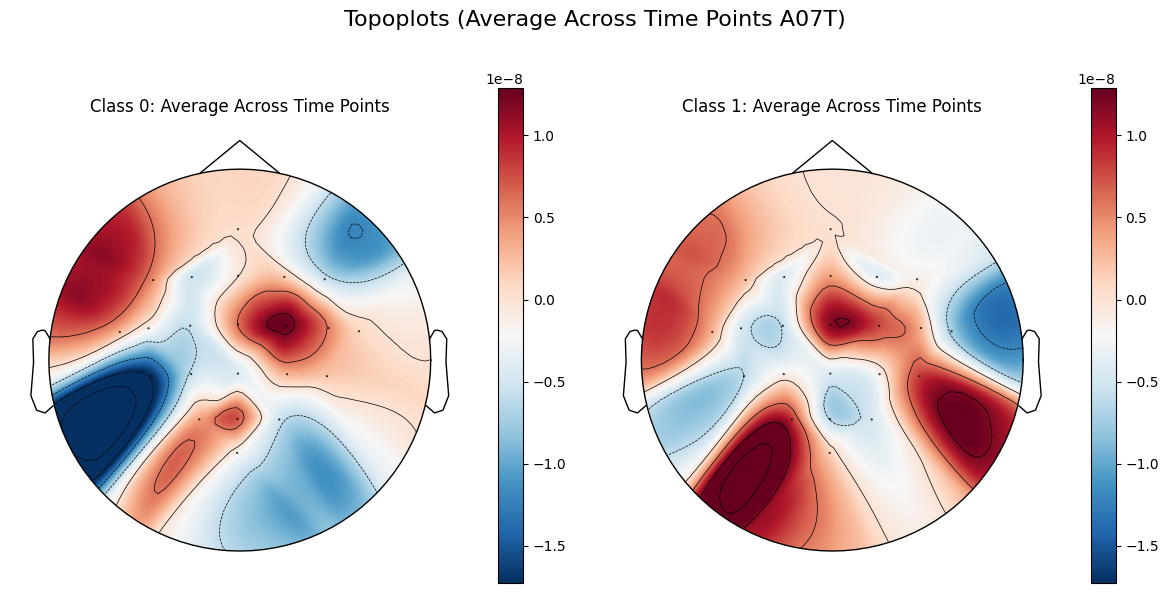

In [144]:
# Step 1: Compute the ERP (average across trials) for each class
erp_class_0 = feature_0.mean(axis=0)  # ERP for class 0
erp_class_1 = feature_1.mean(axis=0)  # ERP for class 1

# Step 2: Average across time points for each channel
avg_erp_class_0 = erp_class_0.mean(axis=1)  # Shape: (channels,)
avg_erp_class_1 = erp_class_1.mean(axis=1)  # Shape: (channels,)

# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (Average Across Time Points {subject_name})", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(avg_erp_class_0.min(), avg_erp_class_1.min())
vmax = max(avg_erp_class_0.max(), avg_erp_class_1.max())

# Class 0
im_0, _ = mne.viz.plot_topomap(avg_erp_class_0, info.info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: Average Across Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(avg_erp_class_1, info.info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: Average Across Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure


In [30]:
filename = '/Users/siddharth/Documents/MATLAB/Examples/R2022b/images/BasicImageImportProcessingAndExportExample/sub07_preprocessed.mat'
from scipy.io import loadmat
data = loadmat(filename)


In [31]:
eeg_data = data['EEG_data'].reshape(144,22,751)

In [32]:
eeg_data.shape

(144, 22, 751)

In [33]:
feature_0 = eeg_data[labels==0]
feature_1 = eeg_data[labels==1]

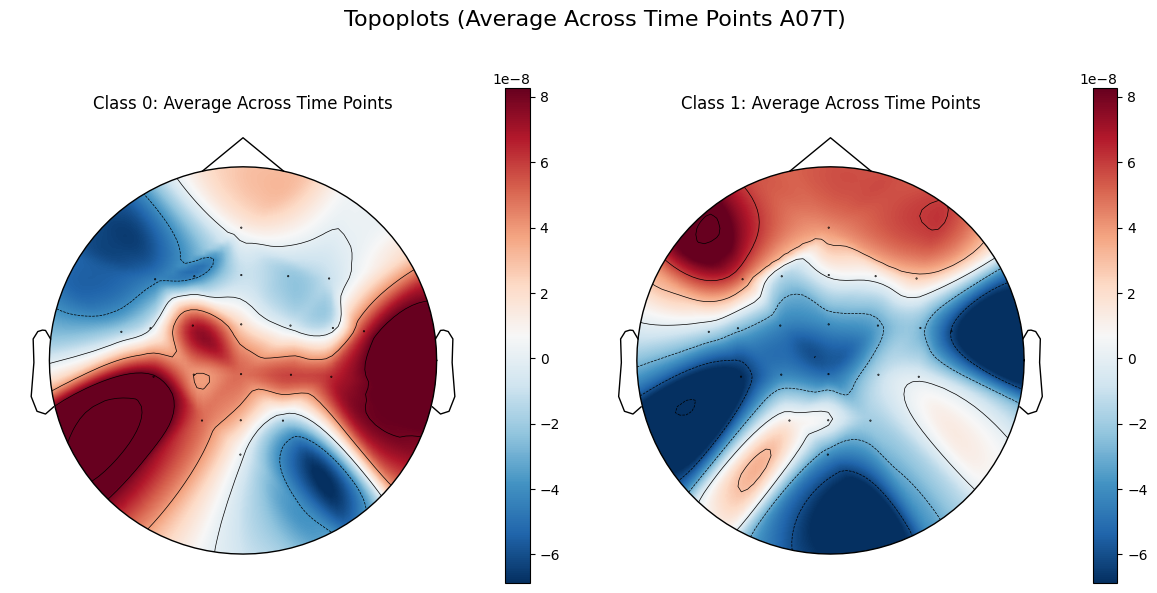

In [34]:
# Step 1: Compute the ERP (average across trials) for each class
erp_class_0 = feature_0.mean(axis=0)  # ERP for class 0
erp_class_1 = feature_1.mean(axis=0)  # ERP for class 1

# Step 2: Average across time points for each channel
avg_erp_class_0 = erp_class_0.mean(axis=1)  # Shape: (channels,)
avg_erp_class_1 = erp_class_1.mean(axis=1)  # Shape: (channels,)

# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (Average Across Time Points {subject_name})", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(avg_erp_class_0.min(), avg_erp_class_1.min())
vmax = max(avg_erp_class_0.max(), avg_erp_class_1.max())

# Class 0
im_0, _ = mne.viz.plot_topomap(avg_erp_class_0, info.info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: Average Across Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(avg_erp_class_1, info.info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: Average Across Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure


### Topoplot after ICA filtering

In [11]:
import matplotlib.pyplot as plt
import mne
import scipy

In [12]:
i = 4
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                          eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',
    'EEG-1': 'FC1',
    'EEG-2': 'FCz',
    'EEG-3': 'FC2',
    'EEG-4': 'FC4',
    'EEG-5': 'C5',
    'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
    'EEG-6': 'C1',
    'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
    'EEG-7': 'C2',
    'EEG-C4' : 'C4',
    'EEG-8': 'C6',
    'EEG-9': 'CP3',
    'EEG-10': 'CP1',
    'EEG-11': 'CPz',
    'EEG-12': 'CP2',
    'EEG-13': 'CP4',
    'EEG-14': 'P1',
    'EEG-Pz': 'Pz',
    'EEG-15': 'P2',
    'EEG-16': 'POz'
}

# Rename the channels using the updated dictionary
raw.rename_channels(channel_rename_dict)

# print(raw.info['ch_names'])

montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
# Step 2: Extract events and create epochs
events = mne.events_from_annotations(raw)

print(events)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

labels = epoch.events[:, -1] - 7

# Step 3: Apply baseline correction
epoch.apply_baseline((-1.5, 0.0))

# Step 4: Ensure data is loaded into memory
epoch.load_data()

# Step 5: Select signal between t = 3 and t = 6
epoch_cropped = epoch.crop(tmin=3, tmax=6)

# Step 7: Extract features for each class
features_769 = epoch_cropped['769'].get_data()  # Features for event 769
features_770 = epoch_cropped['770'].get_data()  # Features for event 770

info = epoch['769'].average()

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A04T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 600914  =      0.000 ...  2403.656 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      3],
       [     0,      0,      2],
       [ 19905,      0,      3],
       ...,
       [597378,      0,      6],
       [598937,      0,      4],
       [599437,      0,      5]]), {'1023': 1, '1072': 2, '32766': 3, '768': 4, '769': 5, '770': 6, '771': 7, '772': 8})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [13]:
import h5py
def recursive_get_data(group, file):
    """
    Recursively traverse the HDF5 group to get all data (including datasets, nested groups, and references).
    """
    data = {}
    
    for key in group:
        item = group[key]
        
        if isinstance(item, h5py.Group):
            # If it's a group, recursively extract its data
            data[key] = recursive_get_data(item, file)
        elif isinstance(item, h5py.Dataset):
            # If it's a dataset, get its value
            data[key] = item[:]
        elif isinstance(item, h5py.Reference):
            # If it's a reference, resolve and retrieve the data
            ref_obj = file[item]
            if isinstance(ref_obj, h5py.Dataset):
                data[key] = ref_obj[:]
            elif isinstance(ref_obj, h5py.Group):
                data[key] = recursive_get_data(ref_obj, file)
            else:
                data[key] = f"Unhandled reference type: {type(ref_obj)}"
            
    return data


In [14]:
# Load the file and extract all data
file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
with h5py.File(file_path, 'r') as f:
    # Extract all data from the file recursively
    all_data = recursive_get_data(f, f)

In [15]:
# all_data['#refs#']['0'].shape

In [16]:
import numpy as np
data = []

# Ensure that '#refs#' is a group and iterate through its keys
for key in all_data['#refs#']:
    # Check if the key corresponds to a group that has a 'data' field
    ref_group = all_data['#refs#'][key]
    if ref_group.shape[0] == 751:
    # Check if the group has a 'data' field
        data.append(ref_group)  # Append the 'data' field to the data list

eeg_data = np.stack(data, axis=0)

In [245]:
eeg_data.shape

(144, 751, 22)

In [246]:
eeg_data = eeg_data.reshape(144,22,751)

In [247]:
feature_0 = eeg_data[labels==0]
feature_1 = eeg_data[labels==1]

In [248]:
info.info

<Info | 10 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG
 custom_ref_applied: True
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2004-11-16 12:00:00 UTC
 nchan: 22
 projs: []
 sfreq: 250.0 Hz
 subject_info: 4 items (dict)
>

In [249]:
# dicts={'class0':feature_0,'class1':feature_1}
# mne.viz.plot_compare_evokeds(dicts)

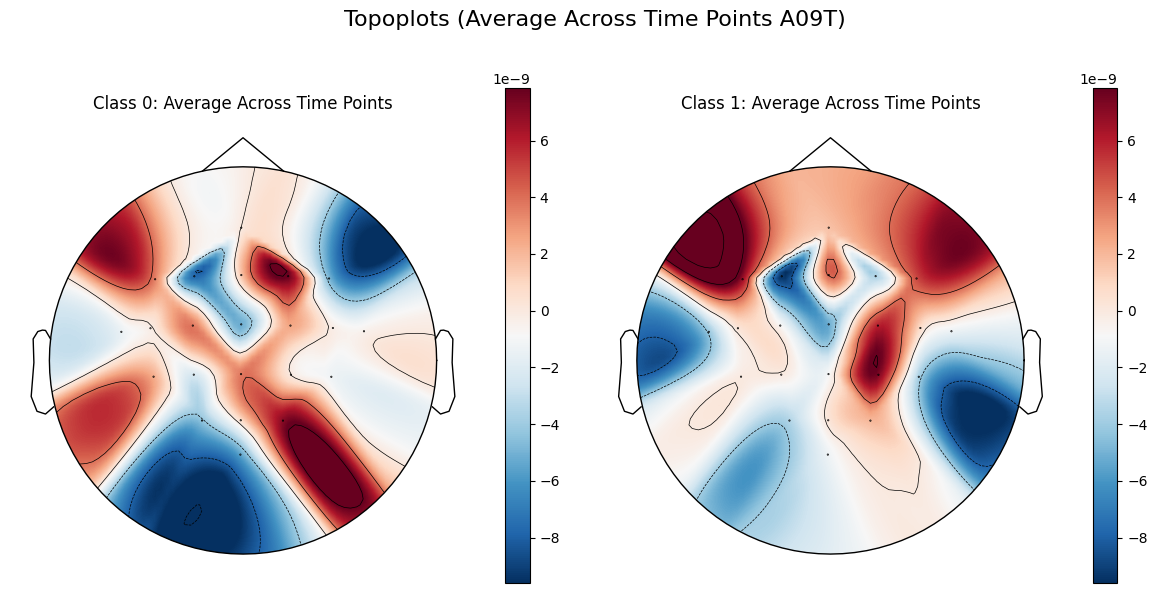

In [250]:
# Step 1: Compute the ERP (average across trials) for each class
# info = create_info_object() 
erp_class_0 = feature_0.mean(axis=0)  # ERP for class 0
erp_class_1 = feature_1.mean(axis=0)  # ERP for class 1

# Step 2: Average across time points for each channel
avg_erp_class_0 = erp_class_0.mean(axis=1)  # Shape: (channels,)
avg_erp_class_1 = erp_class_1.mean(axis=1)  # Shape: (channels,)

# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (Average Across Time Points A0{i}T)", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(avg_erp_class_0.min(), avg_erp_class_1.min())
vmax = max(avg_erp_class_0.max(), avg_erp_class_1.max())

im_0, _ = mne.viz.plot_topomap(avg_erp_class_0, info.info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: Average Across Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(avg_erp_class_1, info.info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: Average Across Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure

1. filter - ica - bandpower plot(calculate bandpower(alpha(8-13) and beta(13-30)) and then make topoplot) (all_subs)

### TopoPlots Bandpower

In [560]:
i = 9
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                          eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',
    'EEG-1': 'FC1',
    'EEG-2': 'FCz',
    'EEG-3': 'FC2',
    'EEG-4': 'FC4',
    'EEG-5': 'C5',
    'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
    'EEG-6': 'C1',
    'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
    'EEG-7': 'C2',
    'EEG-C4' : 'C4',
    'EEG-8': 'C6',
    'EEG-9': 'CP3',
    'EEG-10': 'CP1',
    'EEG-11': 'CPz',
    'EEG-12': 'CP2',
    'EEG-13': 'CP4',
    'EEG-14': 'P1',
    'EEG-Pz': 'Pz',
    'EEG-15': 'P2',
    'EEG-16': 'POz'
}

# Rename the channels using the updated dictionary
raw.rename_channels(channel_rename_dict)

# print(raw.info['ch_names'])

montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
# Step 2: Extract events and create epochs
events = mne.events_from_annotations(raw)

print(events)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

labels = epoch.events[:, -1] - 7

# Step 3: Apply baseline correction
epoch.apply_baseline((-1.5, 0.0))

# Step 4: Ensure data is loaded into memory
epoch.load_data()

# Step 5: Select signal between t = 3 and t = 6
epoch_cropped = epoch.crop(tmin=3, tmax=6)

# Step 7: Extract features for each class
features_769 = epoch_cropped['769'].get_data()  # Features for event 769
features_770 = epoch_cropped['770'].get_data()  # Features for event 770

info = epoch['769'].average()

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [561]:
file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
with h5py.File(file_path, 'r') as f:
    # Extract all data from the file recursively
    all_data = recursive_get_data(f, f)

import numpy as np
data = []

# Ensure that '#refs#' is a group and iterate through its keys
for key in all_data['#refs#']:
    # Check if the key corresponds to a group that has a 'data' field
    ref_group = all_data['#refs#'][key]
    if ref_group.shape[0] == 751:
    # Check if the group has a 'data' field
        data.append(ref_group)  # Append the 'data' field to the data list

eeg_data = np.stack(data, axis=0)

eeg_data = eeg_data.reshape(144,22,751)
# dataset = EpochsArray(eeg_data, )

In [562]:
type(eeg_data)

numpy.ndarray

In [563]:
# Define the sampling frequency (e.g., 1000 Hz)
sfreq = 250

# Define the frequency bands of interest
bands = {
    'alpha': (8, 13),
    'beta': (13, 30),
}

# Function to calculate bandpower for a given frequency band
def bandpower(data, sfreq, band, window_sec=2.0, step_sec=1.0):
    # Compute the Welch Power Spectral Density (PSD) estimate
    f, Pxx = signal.welch(data, sfreq, nperseg=int(window_sec * sfreq))
    
    # Find the frequency range corresponding to the band
    band_idx = np.logical_and(f >= band[0], f <= band[1])
    
    # Integrate the PSD over the frequency band
    band_power = np.trapz(Pxx[band_idx], f[band_idx])  # Integration of the PSD over the band
    return band_power

# Initialize a dictionary to store bandpowers for each band
bandpowers = {band_name: np.zeros((eeg_data.shape[0], eeg_data.shape[1])) for band_name in bands.keys()}

# Loop through each trial and channel
for trial in range(eeg_data.shape[0]):
    for ch in range(eeg_data.shape[1]):
        # Get the EEG signal for this trial and channel
        signal_data = eeg_data[trial, ch, :]
        
        # Calculate bandpower for each band
        for band_name, band in bands.items():
            bandpowers[band_name][trial, ch] = bandpower(signal_data, sfreq, band)

# The `bandpowers` dictionary contains the bandpower values for each trial and channel
print(bandpowers)

{'alpha': array([[2.09861365e-11, 3.59992499e-12, 3.80118834e-12, ...,
        2.19263536e-12, 1.31284559e-12, 9.65727351e-12],
       [3.15135417e-12, 3.28543057e-12, 1.97254302e-12, ...,
        1.80942868e-12, 1.66478975e-12, 4.75706778e-12],
       [1.42867162e-11, 7.97735803e-12, 7.54598557e-12, ...,
        6.46904360e-12, 2.32715497e-12, 6.90268193e-12],
       ...,
       [3.07053250e-12, 1.49760846e-12, 4.51768954e-12, ...,
        1.50689000e-12, 1.98530518e-12, 1.90249781e-12],
       [2.32143989e-12, 2.82171849e-12, 2.21900877e-12, ...,
        5.97579991e-13, 9.94684751e-13, 1.51417889e-12],
       [3.10448023e-12, 2.37723922e-12, 2.30351220e-12, ...,
        2.57274717e-12, 5.50850044e-12, 4.31939493e-12]]), 'beta': array([[3.28727500e-12, 8.98210434e-13, 8.67392882e-13, ...,
        7.20953880e-13, 3.87043765e-13, 2.87834720e-12],
       [2.40756050e-12, 1.18803227e-12, 4.55280936e-13, ...,
        1.18021539e-12, 3.97975481e-13, 1.33500824e-12],
       [3.41393662e-12, 

In [564]:
alpha_bandpower_0 = bandpowers['alpha'][labels == 0]
alpha_bandpower_1 = bandpowers['alpha'][labels == 1]

In [565]:
alpha_bandpower_0 = alpha_bandpower_0.mean(axis=0)
alpha_bandpower_1 = alpha_bandpower_1.mean(axis=0)

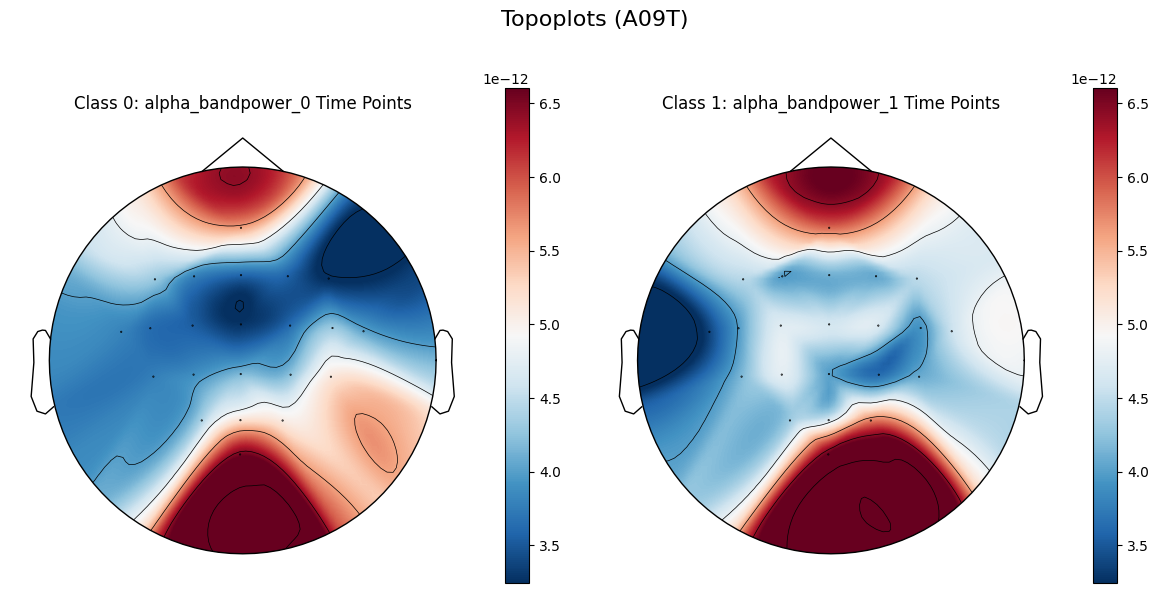

In [566]:
# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (A0{i}T)", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(alpha_bandpower_0.min(), alpha_bandpower_1.min())
vmax = max(alpha_bandpower_0.max(), alpha_bandpower_1.max())

im_0, _ = mne.viz.plot_topomap(alpha_bandpower_0, info.info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: alpha_bandpower_0 Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(alpha_bandpower_1, info.info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: alpha_bandpower_1 Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure

### Unfiltered TopoPlot

In [389]:
subject_name = 'A03T'
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Downloads/BCICIV_2a_gdf/{subject_name}.gdf',
                          eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',
    'EEG-1': 'FC1',
    'EEG-2': 'FCz',
    'EEG-3': 'FC2',
    'EEG-4': 'FC4',
    'EEG-5': 'C5',
    'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
    'EEG-6': 'C1',
    'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
    'EEG-7': 'C2',
    'EEG-C4' : 'C4',
    'EEG-8': 'C6',
    'EEG-9': 'CP3',
    'EEG-10': 'CP1',
    'EEG-11': 'CPz',
    'EEG-12': 'CP2',
    'EEG-13': 'CP4',
    'EEG-14': 'P1',
    'EEG-Pz': 'Pz',
    'EEG-15': 'P2',
    'EEG-16': 'POz'
}

# Rename the channels using the updated dictionary
raw.rename_channels(channel_rename_dict)

# print(raw.info['ch_names'])

montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
# Step 2: Extract events and create epochs
events = mne.events_from_annotations(raw)

print(events)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

labels = epoch.events[:, -1] - 7

# Step 3: Apply baseline correction
epoch.apply_baseline((-1.5, 0.0))

# Step 4: Ensure data is loaded into memory
epoch.load_data()

# Step 5: Select signal between t = 3 and t = 6
epoch_cropped = epoch.crop(tmin=3, tmax=6)
info = epoch_cropped.info
labels = epoch.events[:, -1] - 7

Extracting EDF parameters from /Users/siddharth/Downloads/BCICIV_2a_gdf/A03T.gdf...
GDF file detected


FileNotFoundError: [Errno 2] No such file or directory: '/Users/siddharth/Downloads/BCICIV_2a_gdf/A03T.gdf'

In [80]:
# Load the file and extract all data
file_path = '/Users/siddharth/Documents/Brainconnectivity/unfiltered_Artifacts_removed/unfilt_PreProc_EEG_ICA_filt_sub3.mat'
with h5py.File(file_path, 'r') as f:
    # Extract all data from the file recursively
    all_data = recursive_get_data(f, f)


import numpy as np
data = []

# Ensure that '#refs#' is a group and iterate through its keys
for key in all_data['#refs#']:
    # Check if the key corresponds to a group that has a 'data' field
    ref_group = all_data['#refs#'][key]
    if ref_group.shape[0] == 751:
    # Check if the group has a 'data' field
        data.append(ref_group)  # Append the 'data' field to the data list


eeg_data = np.stack(data, axis=0)
eeg_data = eeg_data.reshape(144,22,751)

In [81]:
import numpy as np
import mne

def filter_eeg_mne(eeg_data, sfreq=250, ch_names=None, lowcut=0.5, highcut=48.0, notch_freq=50.0):
    """
    Filter EEG data using MNE's filtering functions.
    
    Parameters:
    -----------
    eeg_data : numpy.ndarray
        EEG data of shape (n_trials, n_channels, n_timepoints)
    sfreq : float
        Sampling frequency in Hz
    ch_names : list
        List of channel names. If None, will create generic names
    lowcut : float
        Lower frequency bound for bandpass filter
    highcut : float
        Upper frequency bound for bandpass filter
    notch_freq : float
        Frequency to notch filter
        
    Returns:
    --------
    numpy.ndarray
        Filtered EEG data of same shape as input
    """
    # Create channel names if not provided
    if ch_names is None:
        ch_names = [f'CH{i}' for i in range(eeg_data.shape[1])]
    
    # Initialize output array
    filtered_data = np.zeros_like(eeg_data)
    
    # Create info object
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    
    # Process each trial
    for trial in range(eeg_data.shape[0]):
        # Create raw object from trial data
        raw = mne.io.RawArray(eeg_data[trial], info)
        # Apply filters
        raw.notch_filter(freqs=notch_freq)
        raw.filter(l_freq=lowcut, h_freq=highcut)
        
        # Store filtered data
        filtered_data[trial] = raw.get_data()
    
    return filtered_data

# Example usage:
if __name__ == "__main__":
    # Example channel names for BCI Competition IV 2a dataset
    ch_names = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 
                'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 
                'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    
    # Your data shape: (144, 22, 751)
    # eeg_data = ... # Your EEG data here    
    # Filter using MNE
    eeg_data = filter_eeg_mne(eeg_data, ch_names=ch_names)

Creating RawArray with float64 data, n_channels=22, n_times=751
    Range : 0 ... 750 =      0.000 ...     3.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz


- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 48 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 48.00 Hz
- Upper transition bandwidth: 12.00 Hz (-6 dB cutoff frequency: 54.00 Hz)
- Filter length: 1651 samples (6.604 s)

Creating RawArray with float64 data, n_channels=22, n_times=751
    Range : 0 ... 750 =      0.000 ...     3.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- W

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer si

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 48 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 48.00 Hz
- Upper transition bandwidth: 12.00 Hz (-6 dB cutoff frequency: 54.00 Hz)
- Filter length: 1651 samples (6.604 s)

Creating RawArray with float64 data, n_channels=22, n_times=751
    Range : 0 ... 750 =      0.000 ...     3.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a lo

...

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a lo

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 48 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 48.00 Hz
- Upper transition bandwidth: 12.00 Hz (-6 dB cutoff frequency: 54.00 Hz)
- Filter length: 1651 samples (6.604 s)

Creating RawArray with float64 data, n_channels=22, n_times=751
    Range : 0 ... 750 =      0.000 ...     3.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a lo

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 48 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 48.00 Hz
- Upper transition bandwidth: 12.00 Hz (-6 dB cutoff frequency: 54.00 Hz)
- Filter length: 1651 samples (6.604 s)

Creating RawArray with float64 data, n_channels=22, n_times=751
    Range : 0 ... 750 =      0.000 ...     3.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:43: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(freqs=notch_freq)
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_83718/902586197.py:44: RuntimeWarning: filter_length (1651) is longer than the signal (751), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(l_freq=lowcut, h_freq=highcut)


In [82]:
feature_0 = eeg_data[labels==0]
feature_1 = eeg_data[labels==1]

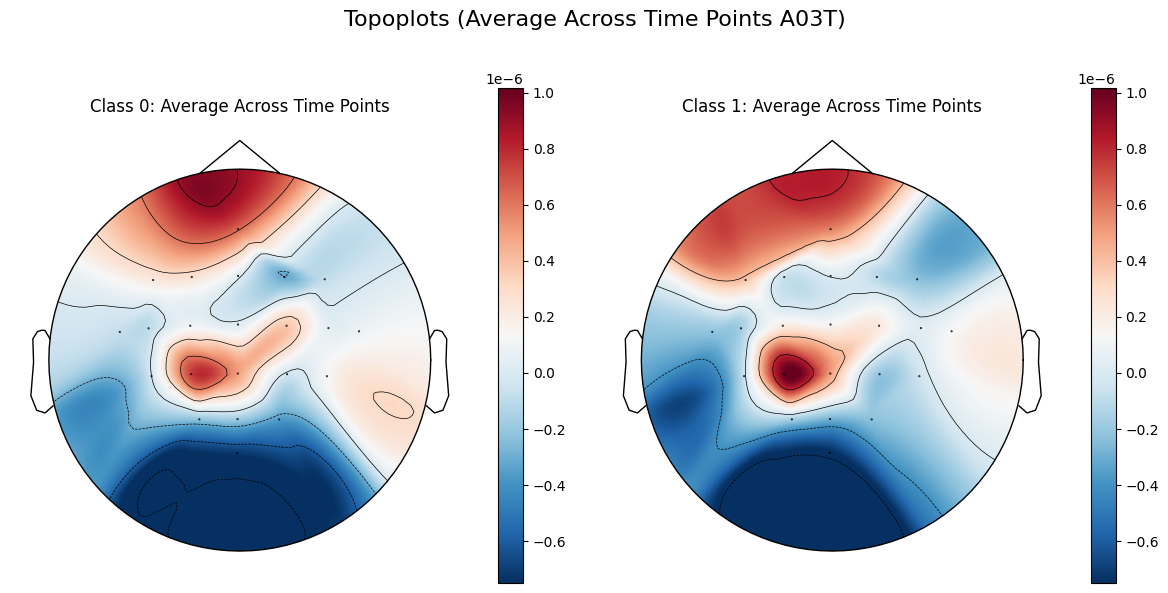

In [83]:
# Step 1: Compute the ERP (average across trials) for each class
info = create_info_object() 
erp_class_0 = feature_0.mean(axis=0)  # ERP for class 0
erp_class_1 = feature_1.mean(axis=0)  # ERP for class 1

# Step 2: Average across time points for each channel
avg_erp_class_0 = erp_class_0.mean(axis=1)  # Shape: (channels,)
avg_erp_class_1 = erp_class_1.mean(axis=1)  # Shape: (channels,)

# Step 3: Plot topoplots for the averaged data
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create figure and axes
fig.suptitle(f"Topoplots (Average Across Time Points {subject_name})", fontsize=16)

# Set the same vmin and vmax for both plots to ensure consistent color scale
vmin = min(avg_erp_class_0.min(), avg_erp_class_1.min())
vmax = max(avg_erp_class_0.max(), avg_erp_class_1.max())

# Class 0
im_0, _ = mne.viz.plot_topomap(avg_erp_class_0, info,
                                axes=axes[0], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[0].set_title("Class 0: Average Across Time Points")

# Class 1
im_1, _ = mne.viz.plot_topomap(avg_erp_class_1, info,
                                axes=axes[1], show=False, cmap='RdBu_r', contours=6,
                                vlim = (vmin,vmax))
axes[1].set_title("Class 1: Average Across Time Points")

# Add colorbars for each plot
fig.colorbar(im_0, ax=axes[0])  # Colorbar for Class 0
fig.colorbar(im_1, ax=axes[1])  # Colorbar for Class 1

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust top spacing to prevent title overlap
plt.show()  # Display the figure

### Extract filteredt ICA data 
##### use extract_filtereted_eeg function - pass i = 0,1,2, and return eeg_data,labels,info

In [741]:
import numpy as np
import mne
import h5py
from scipy.stats import spearmanr

def extract_filtered_eeg(i):
    """ Load, preprocess EEG data, and extract connectivity features. """

    raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                              eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    raw.set_eeg_reference()

    # 🔹 Rename EEG channels for consistency
    channel_rename_dict = {
        'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
        'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4',
        'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
        'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'
    }
    raw.rename_channels(channel_rename_dict)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

    # 🔹 Extract events
    events, event_id = mne.events_from_annotations(raw)
    epoch = mne.Epochs(raw, events, event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, preload=True)

    # 🔹 Extract labels & apply baseline correction
    labels = epoch.events[:, -1] - 7
    labels = np.array(labels)  # Ensure labels are NumPy array
    epoch.apply_baseline((-1.5, 0.0))

    # 🔹 Crop signal from t = 3s to t = 6s
    epoch_cropped = epoch.crop(tmin=3, tmax=6)

    # 🔹 Load filtered EEG data from .mat file
    file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
    
    def recursive_get_data(group, file):
        """ Recursively extract HDF5 data. """
        data = {}
        for key in group:
            item = group[key]
            if isinstance(item, h5py.Group):
                data[key] = recursive_get_data(item, file)
            elif isinstance(item, h5py.Dataset):
                data[key] = item[:]
            elif isinstance(item, h5py.Reference):
                ref_obj = file[item]
                if isinstance(ref_obj, h5py.Dataset):
                    data[key] = ref_obj[:]
                elif isinstance(ref_obj, h5py.Group):
                    data[key] = recursive_get_data(ref_obj, file)
        return data

    with h5py.File(file_path, 'r') as f:
        all_data = recursive_get_data(f, f)

    eeg_data = []
    for key in all_data.get('#refs#', {}):
        ref_group = all_data['#refs#'][key]
        if ref_group.shape[0] == 751:
            eeg_data.append(ref_group)

    eeg_data = np.stack(eeg_data, axis=0).reshape(144, 22, 751)  # Adjust shape if needed

    return eeg_data, labels, epoch['769'].average()

### Phase Lag index

In [3]:
import mne

In [172]:
i = 9
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                          eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',
    'EEG-1': 'FC1',
    'EEG-2': 'FCz',
    'EEG-3': 'FC2',
    'EEG-4': 'FC4',
    'EEG-5': 'C5',
    'EEG-C3': 'C3',  # Assuming EEG-C3 is mapped to C1
    'EEG-6': 'C1',
    'EEG-Cz': 'Cz',  # Assuming EEG-Cz is mapped to C2
    'EEG-7': 'C2',
    'EEG-C4' : 'C4',
    'EEG-8': 'C6',
    'EEG-9': 'CP3',
    'EEG-10': 'CP1',
    'EEG-11': 'CPz',
    'EEG-12': 'CP2',
    'EEG-13': 'CP4',
    'EEG-14': 'P1',
    'EEG-Pz': 'Pz',
    'EEG-15': 'P2',
    'EEG-16': 'POz'
}

# Rename the channels using the updated dictionary
raw.rename_channels(channel_rename_dict)

# print(raw.info['ch_names'])

montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
# Step 2: Extract events and create epochs
events = mne.events_from_annotations(raw)

print(events)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)

labels = epoch.events[:, -1] - 7

# Step 3: Apply baseline correction
epoch.apply_baseline((-1.5, 0.0))

# Step 4: Ensure data is loaded into memory
epoch.load_data()

# Step 5: Select signal between t = 3 and t = 6
epoch_cropped = epoch.crop(tmin=3, tmax=6)

# Step 7: Extract features for each class
features_769 = epoch_cropped['769'].get_data()  # Features for event 769
features_770 = epoch_cropped['770'].get_data()  # Features for event 770

info = epoch['769'].average()

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [173]:
import h5py
def recursive_get_data(group, file):
    """
    Recursively traverse the HDF5 group to get all data (including datasets, nested groups, and references).
    """
    data = {}
    
    for key in group:
        item = group[key]
        
        if isinstance(item, h5py.Group):
            # If it's a group, recursively extract its data
            data[key] = recursive_get_data(item, file)
        elif isinstance(item, h5py.Dataset):
            # If it's a dataset, get its value
            data[key] = item[:]
        elif isinstance(item, h5py.Reference):
            # If it's a reference, resolve and retrieve the data
            ref_obj = file[item]
            if isinstance(ref_obj, h5py.Dataset):
                data[key] = ref_obj[:]
            elif isinstance(ref_obj, h5py.Group):
                data[key] = recursive_get_data(ref_obj, file)
            else:
                data[key] = f"Unhandled reference type: {type(ref_obj)}"
            
    return data


In [174]:
# Load the file and extract all data
file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
with h5py.File(file_path, 'r') as f:
    # Extract all data from the file recursively
    all_data = recursive_get_data(f, f)

In [175]:
import numpy as np
data = []

# Ensure that '#refs#' is a group and iterate through its keys
for key in all_data['#refs#']:
    # Check if the key corresponds to a group that has a 'data' field
    ref_group = all_data['#refs#'][key]
    if ref_group.shape[0] == 751:
    # Check if the group has a 'data' field
        data.append(ref_group)  # Append the 'data' field to the data list

eeg_data = np.stack(data, axis=0)

In [176]:
eeg_data = eeg_data.reshape(144,22,751)

In [177]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [178]:
eeg_data_0.shape

(72, 22, 751)

In [179]:
import numpy as np
from scipy.signal import hilbert

def calculate_pli(data):
    """
    Calculate Phase-Lag Index (PLI) for given dataset.
    
    Args:
        data (numpy.ndarray): Dataset of shape (events, channels, timepoints).
        
    Returns:
        numpy.ndarray: PLI matrix of shape (events, channels, channels).
    """
    events, channels, timepoints = data.shape
    pli_matrix = np.zeros((events, channels, channels))
    
    for event in range(events):
        event_data = data[event]  # Shape: (channels, timepoints)
        
        # Hilbert transform to extract phase information
        analytic_signal = hilbert(event_data, axis=1)
        phases = np.angle(analytic_signal)  # Shape: (channels, timepoints)
        
        # Pairwise phase differences
        for i in range(channels):
            for j in range(i + 1, channels):  # Avoid duplicate calculations
                phase_diff = phases[i] - phases[j]  # Shape: (timepoints,)
                pli_value = np.abs(np.mean(np.sign(np.sin(phase_diff))))
                pli_matrix[event, i, j] = pli_value
                pli_matrix[event, j, i] = pli_value  # Symmetric matrix
    
    return pli_matrix


pli_result_0 = calculate_pli(eeg_data_0)
pli_result_1 = calculate_pli(eeg_data_1)

In [180]:
pli_avg_0 = pli_result_0.mean(axis=0)
pli_avg_1 = pli_result_1.mean(axis=0)

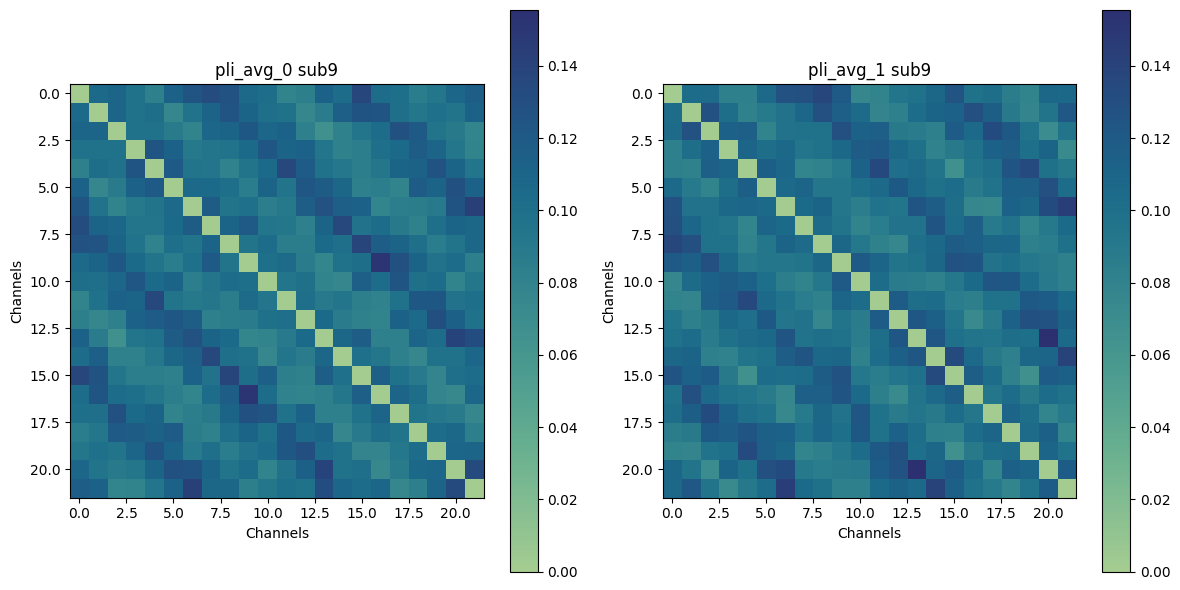

In [181]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(pli_avg_0), np.max(pli_avg_1))
min_value = min(np.min(pli_avg_0), np.min(pli_avg_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for pli_avg_0
heatmap1 = ax1.imshow(pli_avg_0, cmap='crest', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'pli_avg_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for pli_avg_1
heatmap2 = ax2.imshow(pli_avg_1, cmap='crest', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'pli_avg_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### Phase lock value

In [228]:
i = 9
eeg_data,labels,info = extract_filitered_eeg(i)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [229]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [230]:
import numpy as np
from scipy.signal import hilbert

def calculate_plv(data):
    """
    Calculate Phase Locking Value (PLV) for a given dataset.
    
    Args:
        data (numpy.ndarray): Dataset of shape (events, channels, timepoints).
        
    Returns:
        numpy.ndarray: PLV matrix of shape (events, channels, channels).
    """
    events, channels, timepoints = data.shape
    plv_matrix = np.zeros((events, channels, channels))
    
    for event in range(events):
        event_data = data[event]  # Shape: (channels, timepoints)
        
        # Apply Hilbert transform to extract phases
        analytic_signal = hilbert(event_data, axis=1)
        phases = np.angle(analytic_signal)  # Shape: (channels, timepoints)
        
        # Pairwise phase differences
        for i in range(channels):
            for j in range(i + 1, channels):  # Avoid duplicate calculations
                phase_diff = phases[i] - phases[j]  # Shape: (timepoints,)
                
                # Calculate PLV
                plv_value = np.abs(np.mean(np.exp(1j * phase_diff)))
                plv_matrix[event, i, j] = plv_value
                plv_matrix[event, j, i] = plv_value  # Symmetric matrix
    
    return plv_matrix

# Example usage
# Assuming `dataset` is your data array with shape (144, 22, 751)
plv_0 = calculate_plv(eeg_data_0)
plv_1 = calculate_plv(eeg_data_1)

In [231]:
plv_avg_0 = plv_0.mean(axis=0)
plv_avg_1 = plv_1.mean(axis=0)

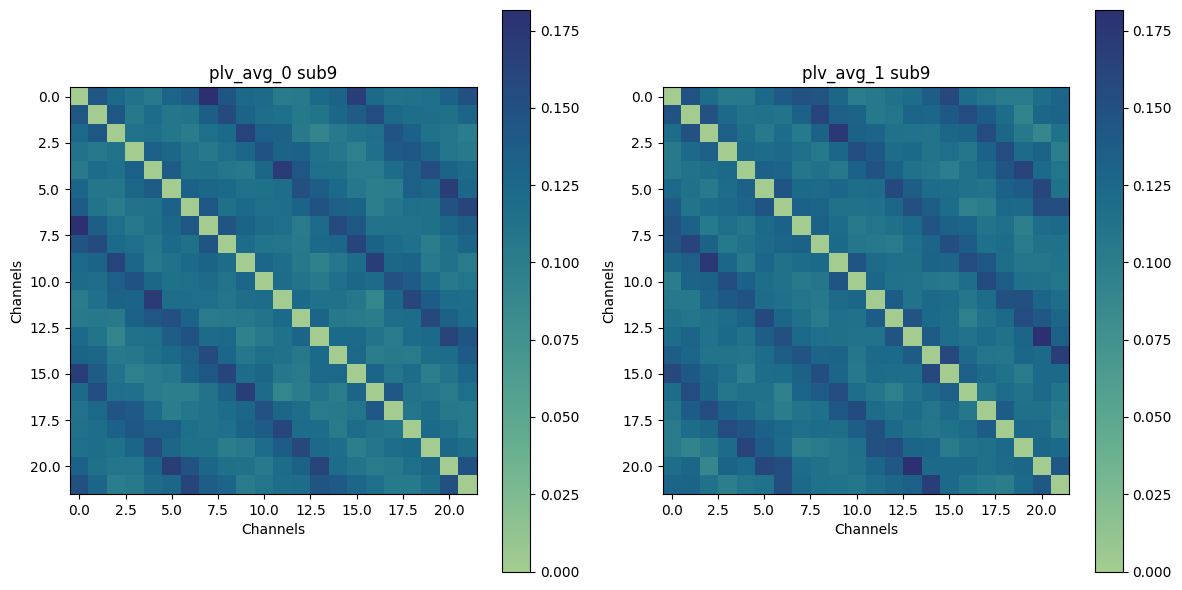

In [232]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(plv_avg_0), np.max(plv_avg_1))
min_value = min(np.min(plv_avg_0), np.min(plv_avg_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for plv_avg_0
heatmap1 = ax1.imshow(plv_avg_0, cmap='crest', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'plv_avg_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for plv_avg_1
heatmap2 = ax2.imshow(plv_avg_1, cmap='crest', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'plv_avg_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### Phase linearity measurement 

In [240]:
i = 4
eeg_data,labels,info = extract_filitered_eeg(i)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A03T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 23720,      0,      5],
       ...,
       [656993,      0,      7],
       [658552,      0,      6],
       [659052,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [241]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [242]:
import numpy as np
from scipy.signal import hilbert

def calculate_plm(data):
    """
    Compute Phase Linearity Measurement (PLM) for a given dataset.
    
    Args:
        data (numpy.ndarray): EEG/MEG data of shape (events, channels, timepoints).
        
    Returns:
        numpy.ndarray: PLM matrix of shape (events, channels, channels).
    """
    events, channels, timepoints = data.shape
    plm_matrix = np.zeros((events, channels, channels))
    
    for event in range(events):
        event_data = data[event]  # Shape: (channels, timepoints)
        
        # Apply Hilbert transform to extract phase information
        analytic_signal = hilbert(event_data, axis=1)
        phases = np.angle(analytic_signal)  # Extract instantaneous phase
        
        # Compute pairwise phase differences and phase linearity
        for i in range(channels):
            for j in range(i + 1, channels):  # Avoid duplicate calculations
                phase_diff = phases[i] - phases[j]  # Shape: (timepoints,)
                
                # Compute Phase Linearity Measure (Circular Variance)
                plm_value = 1 - np.abs(np.mean(np.exp(1j * phase_diff)))
                
                plm_matrix[event, i, j] = plm_value
                plm_matrix[event, j, i] = plm_value  # Symmetric matrix
    
    return plm_matrix

plm_0 = calculate_plm(eeg_data_0)
plm_1 = calculate_plm(eeg_data_1)

In [243]:
plm_avg_0 = plm_0.mean(axis=0)
plm_avg_1 = plm_1.mean(axis=0)

In [244]:
plm_avg_0.shape

(22, 22)

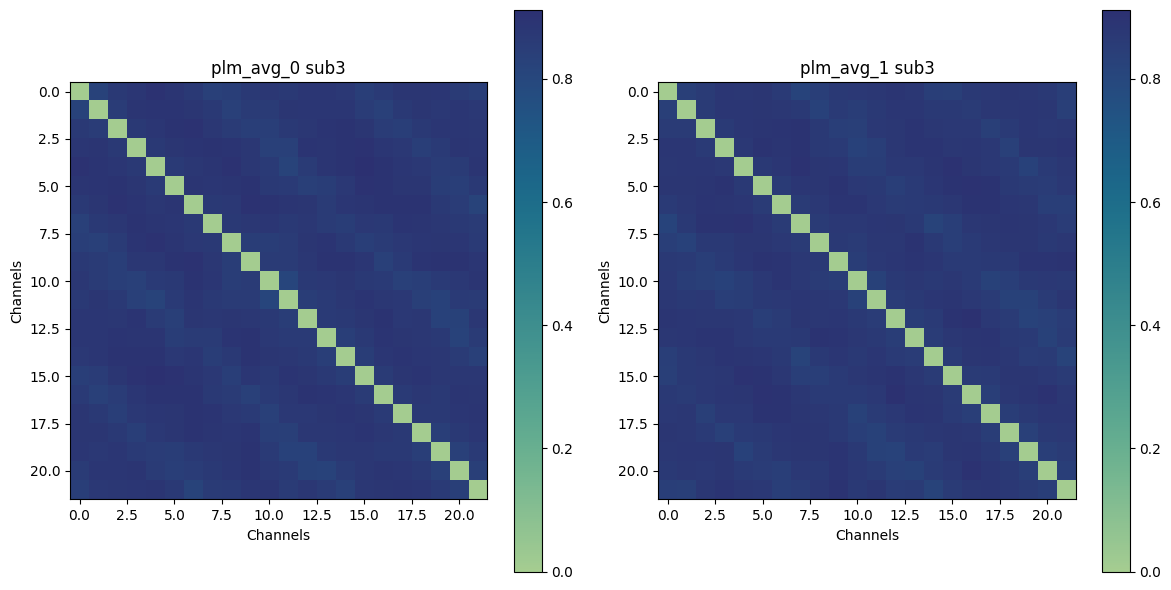

In [245]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(plm_avg_0), np.max(plm_avg_1))
min_value = min(np.min(plm_avg_0), np.min(plm_avg_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for plm_avg_0
heatmap1 = ax1.imshow(plm_avg_0, cmap='crest', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'plm_avg_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for plm_avg_1
heatmap2 = ax2.imshow(plm_avg_1, cmap='crest', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'plm_avg_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### Imagernary part of coherency

In [286]:
import mne

In [735]:
i = 9
eeg_data, labels, info = extract_filitered_eeg(i)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [350]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [351]:
eeg_data_0.shape

(72, 22, 751)

In [352]:
import mne
import numpy as np
from mne_connectivity import spectral_connectivity_epochs
ch_names = [f'EEG{i+1}' for i in range(22)]
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
# Create Epochs object
epochs_0 = mne.EpochsArray(eeg_data_0, info)
epochs_1 = mne.EpochsArray(eeg_data_1, info)
# Calculate imaginary part of coherency
fmin, fmax = 0.5, 48.0  # Frequency range (0 to Nyquist)
connectivity_0 = spectral_connectivity_epochs(
    epochs_0,
    method='imcoh',       # Imaginary coherence
    mode='multitaper',    # Multitaper method
    sfreq=250,
    fmin=fmin,
    fmax=fmax,
    faverage=True,       # Return results per frequency bin
    mt_bandwidth=4.0,     # Time-bandwidth product (default=4.0)
    n_jobs=-1             # Use all available cores
)

connectivity_1 = spectral_connectivity_epochs(
    epochs_1,
    method='imcoh',       # Imaginary coherence
    mode='multitaper',    # Multitaper method
    sfreq=250,
    fmin=fmin,
    fmax=fmax,
    faverage=True,       # Return results per frequency bin
    mt_bandwidth=4.0,     # Time-bandwidth product (default=4.0)
    n_jobs=-1             # Use all available cores
)

Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    computing cross-spectral density for epoch 7
    computing cross-spectral density for ep

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:11: RuntimeWarning: joblib not installed. Cannot run in parallel.
  connectivity_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:11: RuntimeWarning: There were no Annotations stored in <EpochsArray | 72 events (all good), 0 – 3 s (baseline off), ~9.1 MB, data loaded,
 '1': 72>, so metadata was not modified.
  connectivity_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:11: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  connectivity_0 = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 9
    computing cross-spectral density for epoch 10
    computing cross-spectral density for epoch 11
    computing cross-spectral density for epoch 12
    computing cross-spectral density for epoch 13
    computing cross-spectral density for epoch 14
    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
    computing cross-spectral density for epoch 25
    computing cross-spectral density for epoch 26
    computing cross-spectral density for epoch 27
    computing cross-spectral density for epoch 28
 

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:23: RuntimeWarning: joblib not installed. Cannot run in parallel.
  connectivity_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:23: RuntimeWarning: There were no Annotations stored in <EpochsArray | 72 events (all good), 0 – 3 s (baseline off), ~9.1 MB, data loaded,
 '1': 72>, so metadata was not modified.
  connectivity_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:23: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  connectivity_1 = spectral_connectivity_epochs(


    computing cross-spectral density for epoch 12
    computing cross-spectral density for epoch 13
    computing cross-spectral density for epoch 14
    computing cross-spectral density for epoch 15
    computing cross-spectral density for epoch 16
    computing cross-spectral density for epoch 17
    computing cross-spectral density for epoch 18
    computing cross-spectral density for epoch 19
    computing cross-spectral density for epoch 20
    computing cross-spectral density for epoch 21
    computing cross-spectral density for epoch 22
    computing cross-spectral density for epoch 23
    computing cross-spectral density for epoch 24
    computing cross-spectral density for epoch 25
    computing cross-spectral density for epoch 26
    computing cross-spectral density for epoch 27
    computing cross-spectral density for epoch 28
    computing cross-spectral density for epoch 29
    computing cross-spectral density for epoch 30
    computing cross-spectral density for epoch 31


In [353]:
imcoh_conn_0 = connectivity_0.get_data(output="dense")  # (channels, channels, freq_bins)
imcoh_conn_1 = connectivity_1.get_data(output="dense")  # (channels, channels, freq_bins)
imcoh_conn_0 = imcoh_conn_0.reshape(22,22)
imcoh_conn_1 = imcoh_conn_1.reshape(22,22)

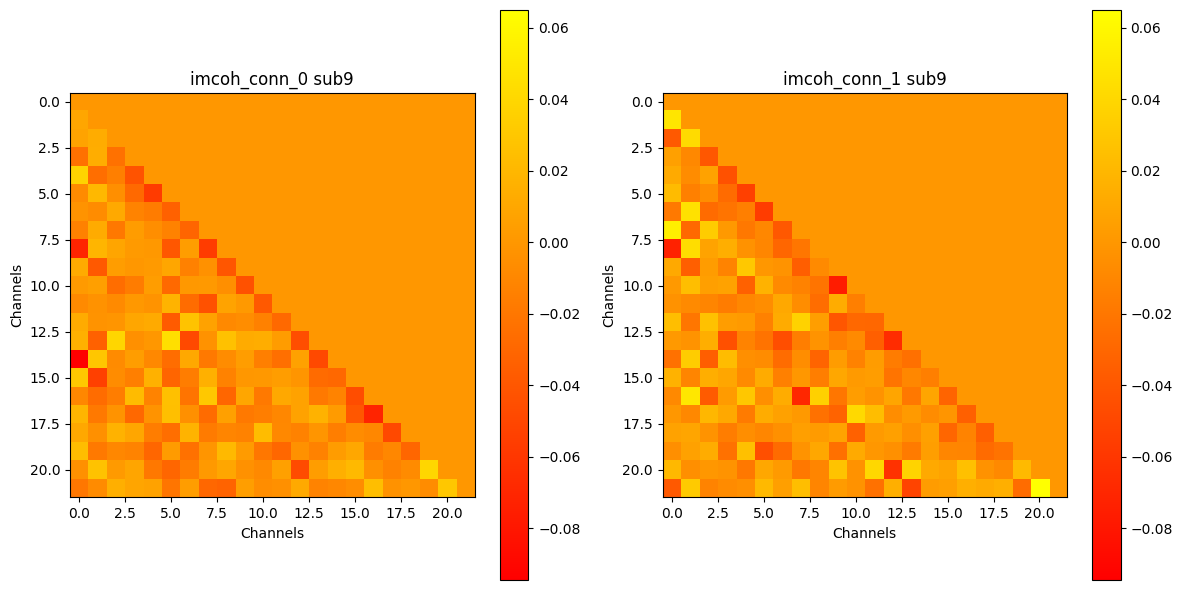

In [355]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(imcoh_conn_0), np.max(imcoh_conn_1))
min_value = min(np.min(imcoh_conn_0), np.min(imcoh_conn_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for imcoh_conn_0
heatmap1 = ax1.imshow(imcoh_conn_0, cmap='autumn', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'imcoh_conn_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for imcoh_conn_1
heatmap2 = ax2.imshow(imcoh_conn_1, cmap='autumn', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'imcoh_conn_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### correlation - Non-Linear Spearman

In [696]:
i=9
eeg_data,labels, info = extract_filitered_eeg(i)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [697]:
import numpy as np
from scipy.stats import spearmanr

def compute_spearman_connectivity(data):
    """
    Computes the Spearman rank correlation-based connectivity for the power signals.
    
    Parameters:
    - data: EEG data of shape (trials, channels, timepoints)
    
    Returns:
    - adjacency_matrices: A NumPy array of shape (trials, channels, channels) representing the connectivity matrices.
    """
    n_trials, n_channels, n_times = data.shape
    adjacency_matrices = []

    for trial in data:
        # Step 1: Compute the power (squared amplitude) of the signal
        # trial = np.abs(trial) ** 2  # Squaring the amplitude to get power
        
        # Step 2: Compute Spearman rank correlation for the power signals across channels
        power_corr = np.zeros((n_channels, n_channels))  # Initialize matrix to store Spearman values
        
        for i in range(n_channels):
            for j in range(i+1, n_channels):
                # Calculate Spearman rank correlation between two channels
                rho, _ = spearmanr(trial[i], trial[j])
                power_corr[i, j] = rho
                power_corr[j, i] = rho  # Spearman correlation is symmetric
        
        # Step 3: Append the computed Spearman correlation matrix for the trial
        adjacency_matrices.append(power_corr)

    # Step 4: Stack the results to form a 3D array: (trials, channels, channels)
    adjacency_matrices = np.stack(adjacency_matrices)
    return np.array(adjacency_matrices)

In [698]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [699]:
corr_0 = compute_connectivity(eeg_data_0)
corr_1 = compute_connectivity(eeg_data_1)

In [700]:
corr_0 = corr_0.mean(axis = 0)
corr_1 = corr_1.mean(axis = 0)

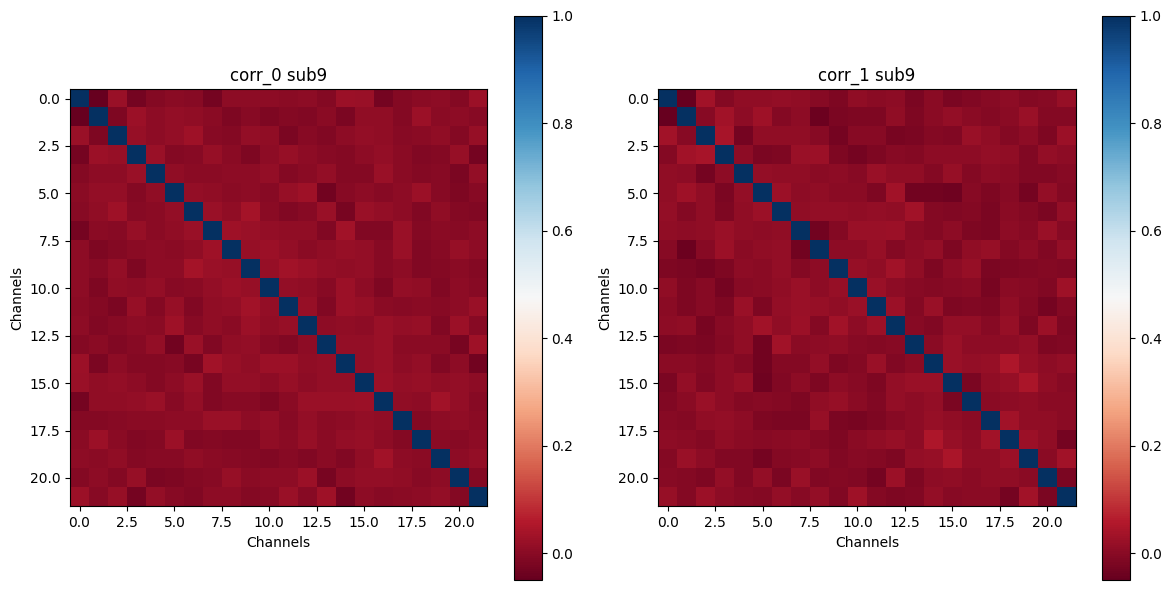

In [701]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(corr_0), np.max(corr_1))
min_value = min(np.min(corr_0), np.min(corr_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for corr_0
heatmap1 = ax1.imshow(corr_0, cmap='RdBu', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'corr_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for corr_1
heatmap2 = ax2.imshow(corr_1, cmap='RdBu', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'corr_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


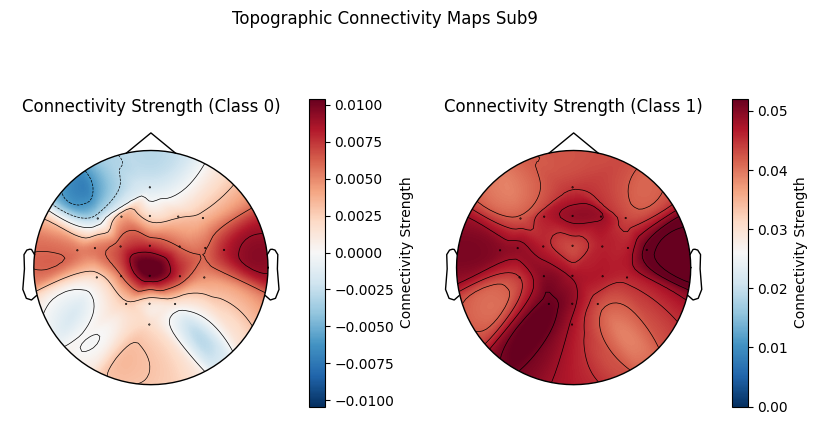

In [500]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# Define channel names (based on your EEG data)
channel_names = [
    "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2", "POz"
]

# Create MNE Info object with standard 10-20 system
montage = mne.channels.make_standard_montage('standard_1020')
info = mne.create_info(ch_names=channel_names, sfreq=250, ch_types='eeg')
info.set_montage(montage)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot topographic connectivity for corr_0
im1, _ = mne.viz.plot_topomap(corr_0.mean(axis=0), info, axes=axes[0], show=False, cmap='RdBu_r')
axes[0].set_title("Connectivity Strength (Class 0)")
cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.8)
cbar1.set_label("Connectivity Strength")

# Plot topographic connectivity for corr_1
im2, _ = mne.viz.plot_topomap(corr_1.mean(axis=0), info, axes=axes[1], show=False, cmap='RdBu_r')
axes[1].set_title("Connectivity Strength (Class 1)")
cbar2 = plt.colorbar(im2, ax=axes[1], shrink=0.8)
cbar2.set_label("Connectivity Strength")

# Display the plots
plt.suptitle(f"Topographic Connectivity Maps Sub{i}")
plt.show()

### Amplitude Corr - Non Linear & Linear

In [544]:
i=8
eeg_data,labels, info = extract_filitered_eeg(i)

eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30571,      0,      5],
       ...,
       [671733,      0,      7],
       [673292,      0,      6],
       [673792,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [546]:
import numpy as np
from scipy.stats import spearmanr

def compute_amplitude_connectivity(data):
    """
    Computes the amplitude correlation-based connectivity using Spearman correlation.
    
    Parameters:
    - data: EEG/MEG data of shape (trials, channels, timepoints)
    
    Returns:
    - adjacency_matrices: A NumPy array of shape (trials, channels, channels) representing the connectivity matrices.
    """
    n_trials, n_channels, n_times = data.shape
    adjacency_matrices = []

    for trial in data:
        # Compute amplitude (absolute value)
        amplitude_data = np.abs(trial)
        
        # Compute Spearman correlation for amplitude
        spearman_corr, _ = spearmanr(amplitude_data, axis=1)
        
        adjacency_matrices.append(spearman_corr)

    adjacency_matrices = np.stack(adjacency_matrices)
    return np.array(adjacency_matrices)

In [547]:
corr_0 = compute_amplitude_connectivity(eeg_data_0)
corr_1 = compute_amplitude_connectivity(eeg_data_1)

In [548]:
corr_1 = corr_1.mean(axis = 0)
corr_0 = corr_0.mean(axis = 0)

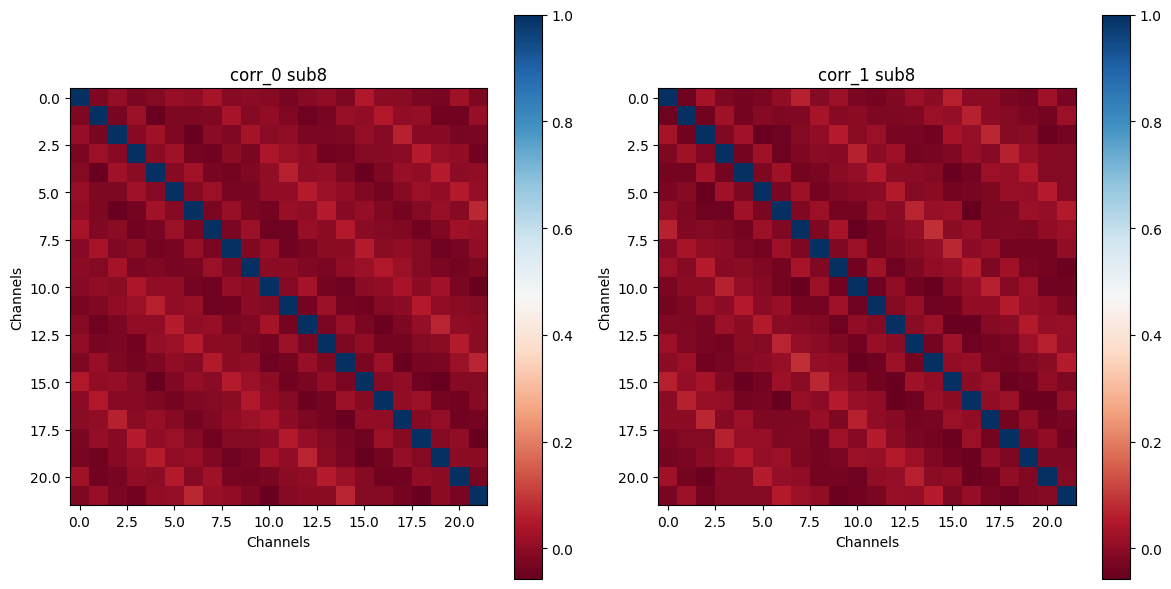

In [549]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(corr_0), np.max(corr_1))
min_value = min(np.min(corr_0), np.min(corr_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for corr_0
heatmap1 = ax1.imshow(corr_0, cmap='RdBu', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'corr_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for corr_1
heatmap2 = ax2.imshow(corr_1, cmap='RdBu', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'corr_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


Linear

In [594]:
i=9
eeg_data,labels, info = extract_filitered_eeg(i)

eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [595]:
import numpy as np

def compute_amplitude_connectivity(data):
    """
    Computes the amplitude correlation-based connectivity using Pearson correlation.
    
    Parameters:
    - data: EEG/MEG data of shape (trials, channels, timepoints)
    
    Returns:
    - adjacency_matrices: A NumPy array of shape (trials, channels, channels) representing the connectivity matrices.
    """
    n_trials, n_channels, n_times = data.shape
    adjacency_matrices = []

    for trial in data:
        # Compute amplitude (absolute value)
        amplitude_data = np.abs(trial)
        
        # Compute Pearson correlation for amplitude (using np.corrcoef)
        # Transpose amplitude_data to have channels as rows for correlation computation
        pearson_corr = np.corrcoef(amplitude_data)
        
        # Append the computed correlation matrix for the trial
        adjacency_matrices.append(pearson_corr)

    # Stack the results to form a 3D array: (trials, channels, channels)
    adjacency_matrices = np.stack(adjacency_matrices)
    return np.array(adjacency_matrices)


In [596]:
corr_0 = compute_amplitude_connectivity(eeg_data_0)
corr_1 = compute_amplitude_connectivity(eeg_data_1)

In [597]:
corr_0 = corr_0.mean(axis = 0)
corr_1 = corr_1.mean(axis = 0)

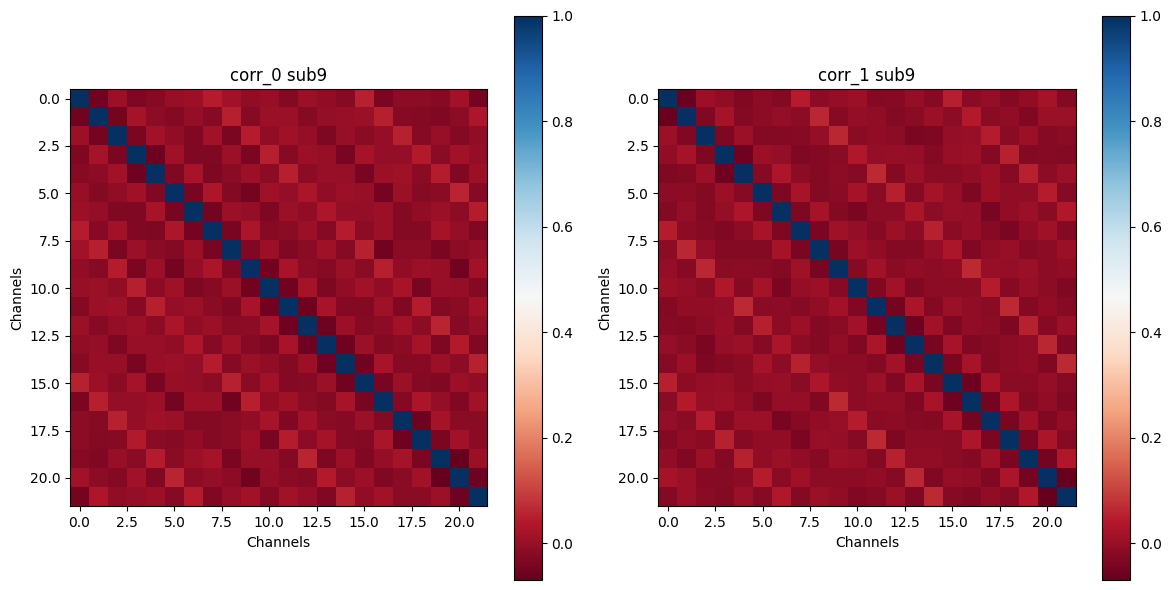

In [598]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(corr_0), np.max(corr_1))
min_value = min(np.min(corr_0), np.min(corr_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for corr_0
heatmap1 = ax1.imshow(corr_0, cmap='RdBu', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'corr_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for corr_1
heatmap2 = ax2.imshow(corr_1, cmap='RdBu', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'corr_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### Power Corr - Linear and Non - Linear

In [639]:
i=9
eeg_data,labels, info = extract_filitered_eeg(i)

eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [640]:
import numpy as np

def compute_power_connectivity(data):
    """
    Computes the power correlation-based connectivity using Pearson correlation.
    
    Parameters:
    - data: EEG data of shape (trials, channels, timepoints)
    
    Returns:
    - adjacency_matrices: A NumPy array of shape (trials, channels, channels) representing the connectivity matrices.
    """
    n_trials, n_channels, n_times = data.shape
    adjacency_matrices = []

    for trial in data:
        # Step 1: Compute the power (squared amplitude) of the signal
        power_data = np.abs(trial) ** 2  # Squaring the amplitude to get power
        
        # Step 2: Compute Pearson correlation for the power (using np.corrcoef)
        power_corr = np.corrcoef(power_data)
        
        # Step 3: Append the computed correlation matrix for the trial
        adjacency_matrices.append(power_corr)

    # Step 4: Stack the results to form a 3D array: (trials, channels, channels)
    adjacency_matrices = np.stack(adjacency_matrices)
    return np.array(adjacency_matrices)


In [641]:
corr_1 = compute_power_connectivity(eeg_data_1)
corr_0 = compute_power_connectivity(eeg_data_0)

In [642]:
corr_0 = corr_0.mean(axis = 0)
corr_1 = corr_1.mean(axis = 0)

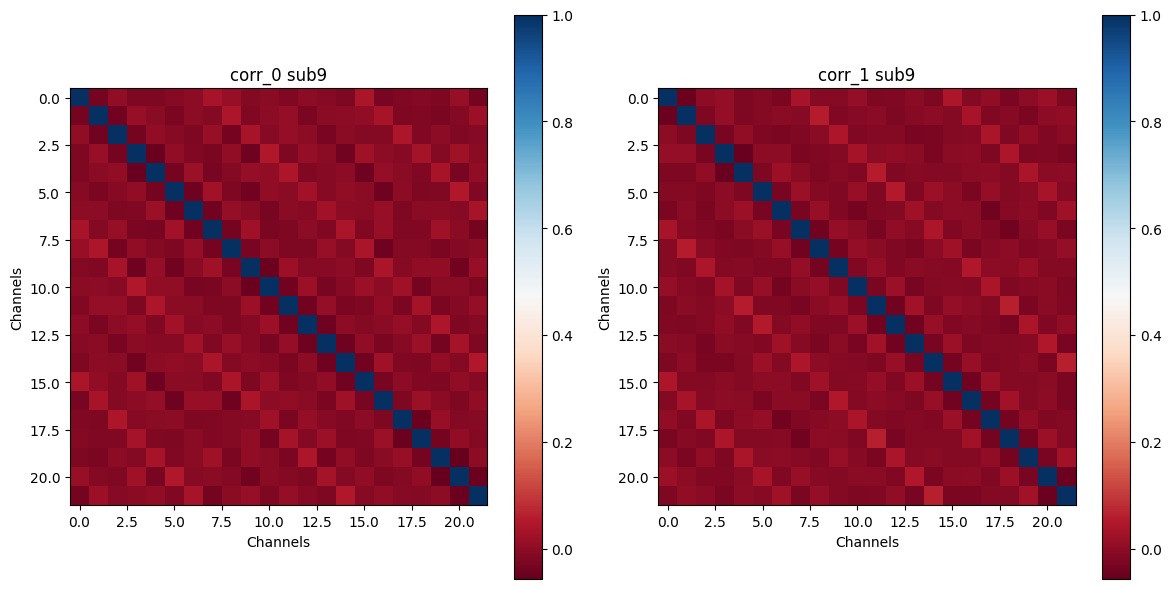

In [643]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(corr_0), np.max(corr_1))
min_value = min(np.min(corr_0), np.min(corr_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for corr_0
heatmap1 = ax1.imshow(corr_0, cmap='RdBu', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'corr_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for corr_1
heatmap2 = ax2.imshow(corr_1, cmap='RdBu', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'corr_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


Non - linear

In [690]:
i=9
eeg_data,labels, info = extract_filitered_eeg(i)

eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30878,      0,      5],
       ...,
       [669791,      0,      8],
       [671350,      0,      6],
       [671850,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [691]:
import numpy as np
from scipy.stats import spearmanr

def compute_spearman_connectivity(data):
    """
    Computes the Spearman rank correlation-based connectivity for the power signals.
    
    Parameters:
    - data: EEG data of shape (trials, channels, timepoints)
    
    Returns:
    - adjacency_matrices: A NumPy array of shape (trials, channels, channels) representing the connectivity matrices.
    """
    n_trials, n_channels, n_times = data.shape
    adjacency_matrices = []

    for trial in data:
        # Step 1: Compute the power (squared amplitude) of the signal
        power_data = np.abs(trial) ** 2  # Squaring the amplitude to get power
        
        # Step 2: Compute Spearman rank correlation for the power signals across channels
        power_corr = np.zeros((n_channels, n_channels))  # Initialize matrix to store Spearman values
        
        for i in range(n_channels):
            for j in range(i+1, n_channels):
                # Calculate Spearman rank correlation between two channels
                rho, _ = spearmanr(power_data[i], power_data[j])
                power_corr[i, j] = rho
                power_corr[j, i] = rho  # Spearman correlation is symmetric
        
        # Step 3: Append the computed Spearman correlation matrix for the trial
        adjacency_matrices.append(power_corr)

    # Step 4: Stack the results to form a 3D array: (trials, channels, channels)
    adjacency_matrices = np.stack(adjacency_matrices)
    return np.array(adjacency_matrices)

In [692]:
corr_1 = compute_spearman_connectivity(eeg_data_1)
corr_0 = compute_spearman_connectivity(eeg_data_0)

In [693]:
corr_0 = corr_0.mean(axis = 0)
corr_1 = corr_1.mean(axis = 0)

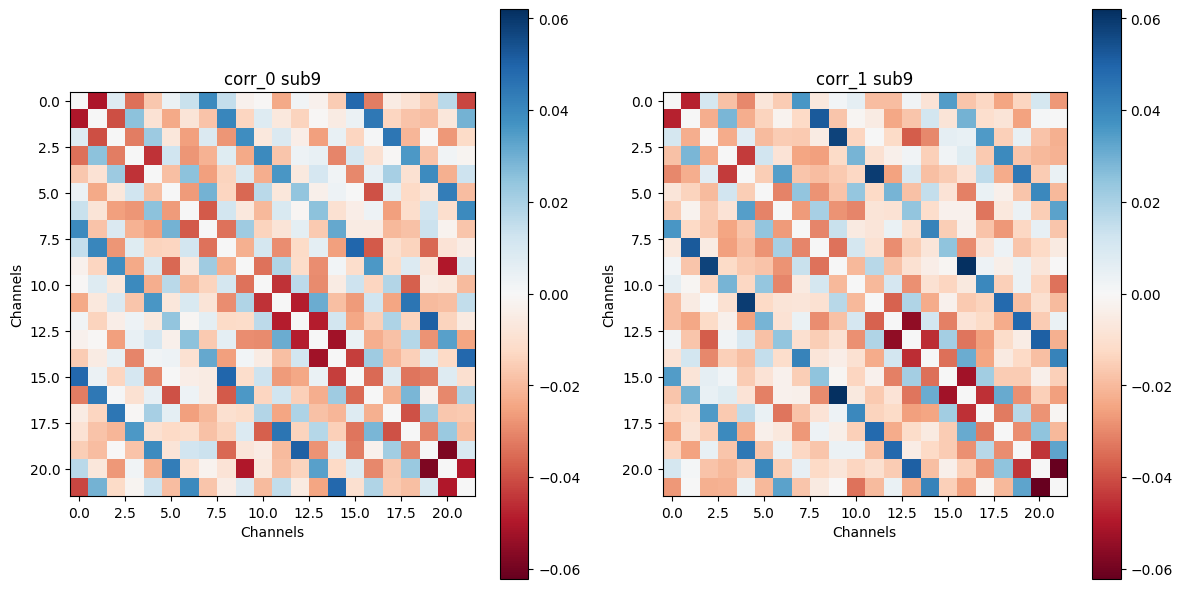

In [694]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the maximum and minimum values from both matrices
max_value = max(np.max(corr_0), np.max(corr_1))
min_value = min(np.min(corr_0), np.min(corr_1))

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot heatmap for corr_0
heatmap1 = ax1.imshow(corr_0, cmap='RdBu', vmin=min_value, vmax=max_value)
ax1.set_xlabel('Channels')
ax1.set_ylabel('Channels')
ax1.set_title(f'corr_0 sub{i}')
fig.colorbar(heatmap1, ax=ax1)

# Plot heatmap for corr_1
heatmap2 = ax2.imshow(corr_1, cmap='RdBu', vmin=min_value, vmax=max_value)
ax2.set_xlabel('Channels')
ax2.set_ylabel('Channels')
ax2.set_title(f'corr_1 sub{i}')
fig.colorbar(heatmap2, ax=ax2)

# Adjust layout to make space for colorbars
plt.tight_layout()
plt.show()


### Extract Features

In [724]:
import scipy.io

# Path to your .mat file
file_path = '/Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub8_features.mat'

# Load the .mat file
data = scipy.io.loadmat(file_path)

# Print the keys in the loaded data
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Feature', 'auc', 'kurtosisPower', 'kurtosisVal', 'latency', 'maximumPower', 'meanAbsoluteAmplitude', 'meanPower', 'peakAmplitude', 'peakToPeakAmplitude', 'rmsAmplitude', 'skewnessPower', 'skewnessVal', 'slope', 'spectralEntropy', 'standardDeviation', 'variancePower', 'zork'])


In [727]:
eeg_data, labels, info = extract_filitered_eeg(8)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 30571,      0,      5],
       ...,
       [671733,      0,      7],
       [673292,      0,      6],
       [673792,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [728]:
epoch_0 = eeg_data[labels == 0]
epoch_1 = eeg_data[labels == 1]

In [729]:
import mne
import numpy as np
from mne_connectivity import spectral_connectivity_epochs
ch_names = [f'EEG{i+1}' for i in range(22)]
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
# Create Epochs object
epochs_0 = mne.EpochsArray(eeg_data_0, info)
epochs_1 = mne.EpochsArray(eeg_data_1, info)
# Calculate imaginary part of coherency
fmin, fmax = 0.5, 48.0  # Frequency range (0 to Nyquist)
connectivity_0 = spectral_connectivity_epochs(
    epochs_0,
    method='imcoh',       # Imaginary coherence
    mode='multitaper',    # Multitaper method
    sfreq=250,
    fmin=fmin,
    fmax=fmax,
    faverage=True,       # Return results per frequency bin
    mt_bandwidth=4.0,     # Time-bandwidth product (default=4.0)
    n_jobs=-1             # Use all available cores
)

connectivity_1 = spectral_connectivity_epochs(
    epochs_1,
    method='imcoh',       # Imaginary coherence
    mode='multitaper',    # Multitaper method
    sfreq=250,
    fmin=fmin,
    fmax=fmax,
    faverage=True,       # Return results per frequency bin
    mt_bandwidth=4.0,     # Time-bandwidth product (default=4.0)
    n_jobs=-1             # Use all available cores
)

Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated


Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..8


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:11: RuntimeWarning: There were no Annotations stored in <EpochsArray | 72 events (all good), 0 – 3 s (baseline off), ~9.1 MB, data loaded,
 '1': 72>, so metadata was not modified.
  connectivity_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_35039/4265264729.py:11: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  connectivity_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   11.5s remaining:   19.2s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   11.7s remaining:    7.0s


    computing cross-spectral density for epochs 9..16


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   11.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.6s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.7s remaining:    0.4s


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    computing cross-spectral density for epochs 65..72


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.2s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.2s finished


In [732]:
imcoh_conn_0 = connectivity_0.get_data(output="dense")  # (channels, channels, freq_bins)
imcoh_conn_1 = connectivity_1.get_data(output="dense")  # (channels, channels, freq_bins)
imcoh_conn_0 = imcoh_conn_0.reshape(22,22)
imcoh_conn_1 = imcoh_conn_1.reshape(22,22)

(22, 22)

In [744]:
for i in range(2, 10):
    eeg_data, labels, info = extract_filtered_eeg(i)
    save_path = f'/Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub{i}.mat'
    savemat(save_path, {'eeg_data': eeg_data, 'labels': labels})
    print(f'Saved {save_path}')

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A02T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Saved /Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub2.mat
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A03T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ..

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Saved /Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub3.mat
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A04T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ..

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Saved /Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub7.mat
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ..

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Saved /Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub8.mat
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A09T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ..

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Saved /Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub9.mat
